## Analyze performance gap between ICEBERG and Siamese Model

In [1]:
import pandas as pd
import numpy as np

# --- 1. CONFIGURATION ---
# Paths from your environment
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
MOL_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"

TARGET_FPR = 0.05

# --- 2. LOAD RESULTS & FIND GLOBAL BASELINES ---
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)

# Use the full Siamese test set labels for global baseline
TOTAL_NEG_GLOBAL = (df_sia['true_label'] == 0).sum()
TOTAL_POS_GLOBAL = (df_sia['true_label'] == 1).sum()
ERROR_BUDGET = int(TOTAL_NEG_GLOBAL * TARGET_FPR)

# --- 3. IDENTIFY ICEBERG CONFIDENT ZONE ---
# Rank by confidence (|Score - 0.5|)
df_ice['confidence_ice'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('confidence_ice', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()

# Filter to results within 5% FPR budget
ice_fair_subset = df_ice_sorted[df_ice_sorted['cum_fp'] <= ERROR_BUDGET].copy()

# --- 4. MERGE WITH SIAMESE & DETECT MISSES ---
# Define Siamese confidence
df_sia['confidence_sia'] = np.abs(df_sia['prob_similarity'] - 0.5)

merged = pd.merge(
    ice_fair_subset[['name_main', 'name_sub', 'true_label', 'cosine_similarity', 'confidence_ice']],
    df_sia[['name_main', 'name_sub', 'prob_similarity', 'confidence_sia']],
    on=['name_main', 'name_sub'],
    suffixes=('_ice', '_sia')
)

# MISS CRITERIA:
# 1. True Positive (Match)
# 2. ICEBERG correctly predicted 1 (confident zone)
# 3. Siamese was WRONG (prob < 0.5) OR Siamese was UNCERTAIN (low confidence)
misses = merged[
    (merged['true_label'] == 1) & 
    (merged['cosine_similarity'] >= 0.5) & 
    ((merged['prob_similarity'] < 0.5) | (merged['confidence_sia'] < 0.2))
].copy()

# Sort by the "Trust Gap" (How much ICEBERG beat Siamese)
misses['trust_gap'] = misses['cosine_similarity'] - misses['prob_similarity']
misses = misses.sort_values('trust_gap', ascending=False)

# --- 5. ENRICH WITH METADATA ---
print(f"Loading metadata from {SPEC_DATA_PATH}...")
spec_df = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')
mol_df = pd.read_pickle(MOL_DATA_PATH).set_index('mol_id')

def get_pair_meta(row):
    try:
        s_main = spec_df.loc[row['name_main']]
        s_sub = spec_df.loc[row['name_sub']]
        m_main = mol_df.loc[s_main['mol_id']]
        m_sub = mol_df.loc[s_sub['mol_id']]
        
        return pd.Series({
            'smiles_main': m_main['smiles'],
            'smiles_sub': m_sub['smiles'],
            'mz_main': s_main['prec_mz'],
            'mz_sub': s_sub['prec_mz'],
            'mass_diff': abs(s_main['prec_mz'] - s_sub['prec_mz']),
            'peaks_main': s_main['peaks'],
            'peaks_sub': s_sub['peaks']
        })
    except:
        return pd.Series([None]*7)

# Apply to the misses
diagnostic_df = pd.concat([misses, misses.apply(get_pair_meta, axis=1)], axis=1)

# Export for inspection
diagnostic_df.to_csv("global_iceberg_wins_siamese_misses.csv", index=False)
print(f"Exported {len(diagnostic_df)} pairs to global_iceberg_wins_siamese_misses.csv")

Loading metadata from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl...
Exported 99 pairs to global_iceberg_wins_siamese_misses.csv


In [2]:
diagnostic_df.head()

,name_main,name_sub,true_label,cosine_similarity,confidence_ice,prob_similarity,confidence_sia,trust_gap,smiles_main,smiles_sub,mz_main,mz_sub,mass_diff,peaks_main,peaks_sub
304,MassSpecGymID0039738,MassSpecGymID0067621,1.0,0.994662,0.494662,0.137590,0.362410,0.857072,c1ccc2c(c1)[nH]c1ccncc12,Oc1cccc2nc3ccccc3nc12,169.07600,197.07090,27.99490,"[(113.038, 0.00624543), (114.0456, 0.01434609)...","[(75.0223, 0.04804804804804805), (78.0331, 0.0..."
302,MassSpecGymID0029502,MassSpecGymID0067624,1.0,0.994958,0.494958,0.171437,0.328563,0.823522,c1ccc2c(c1)[nH]c1ncccc12,Oc1cccc2nc3ccccc3nc12,169.07600,197.07090,27.99490,"[(113.038, 0.006006006006006006), (114.0456, 0...","[(61.0071, 0.0012239500000000001), (68.9977, 0..."
303,MassSpecGymID0029510,MassSpecGymID0067621,1.0,0.994958,0.494958,0.185677,0.314323,0.809281,c1ccc2c(c1)[nH]c1ncccc12,Oc1cccc2nc3ccccc3nc12,169.07600,197.07090,27.99490,"[(113.038, 0.00624543), (114.0456, 0.01434609)...","[(75.0223, 0.04804804804804805), (78.0331, 0.0..."
474,MassSpecGymID0227730,MassSpecGymID0230733,1.0,0.957726,0.457726,0.187193,0.312807,0.770533,CCc1ccc(C(=O)C(C)CN2CCCCC2)cc1,Cc1cc(C(=O)CN2CCCCC2)c(C)n1-c1ccc(Cl)cc1,260.20089,331.15717,70.95628,"[(41.038567, 0.004), (42.033783, 0.00938999999...","[(42.033821, 0.00621), (44.049374, 0.01179), (..."
830,MassSpecGymID0228246,MassSpecGymID0232298,1.0,0.853492,0.353492,0.085477,0.414523,0.768015,CN1CCC(c2c[nH]c3ccc(O)cc23)CC1,CNS(=O)(=O)CCc1ccc2[nH]cc(C3CCN(C)CC3)c2c1,231.14919,336.17402,105.02483,"[(41.038712, 0.00246), (42.033791, 0.028679999...","[(42.033787, 0.01591), (44.049389, 0.04714), (..."


## Analyze spectral qualities of missed pairs

In [3]:
import pandas as pd
import numpy as np

def calculate_spectral_diagnostics(peaks_a, peaks_b, prec_a, prec_b, tol=0.01):
    """
    Analyzes shared anchor peaks, neutral losses, and complexity between two spectra.
    """
    if not isinstance(peaks_a, list) or not isinstance(peaks_b, list):
        return pd.Series([None]*5)
    
    # 1. PEAK DENSITY & COMPLEXITY
    n_peaks_a = len(peaks_a)
    n_peaks_b = len(peaks_b)
    
    # 2. ANCHOR PEAKS (Top 5 most intense)
    top_a = sorted(peaks_a, key=lambda x: x[1], reverse=True)[:5]
    top_b = sorted(peaks_b, key=lambda x: x[1], reverse=True)[:5]
    
    shared_anchors = 0
    for mz_a, int_a in top_a:
        for mz_b, int_b in top_b:
            if abs(mz_a - mz_b) <= tol:
                shared_anchors += 1
                
    # 3. NEUTRAL LOSS PATTERNS
    # Calculate losses: Precursor m/z - fragment m/z
    losses_a = [prec_a - p[0] for p in peaks_a if p[0] < prec_a]
    losses_b = [prec_b - p[0] for p in peaks_b if p[0] < prec_b]
    
    shared_losses = 0
    # Check if top intensity losses are conserved
    top_losses_a = sorted([(prec_a - p[0], p[1]) for p in peaks_a], key=lambda x: x[1], reverse=True)[:10]
    top_losses_b = sorted([(prec_b - p[0], p[1]) for p in peaks_b], key=lambda x: x[1], reverse=True)[:10]
    
    for l_a, _ in top_losses_a:
        for l_b, _ in top_losses_b:
            if abs(l_a - l_b) <= tol:
                shared_losses += 1

    return pd.Series({
        'n_peaks_avg': (n_peaks_a + n_peaks_b) / 2,
        'shared_top_5_anchors': shared_anchors,
        'shared_top_10_losses': shared_losses,
        'complexity_ratio': abs(n_peaks_a - n_peaks_b) / max(n_peaks_a, n_peaks_b) if max(n_peaks_a, n_peaks_b) > 0 else 0
    })

# --- EXECUTION ---
# Load your exported diagnostic file if needed
# diagnostic_df = pd.read_csv("global_iceberg_wins_siamese_misses.csv")

print("Analyzing spectral factors...")
spectral_stats = diagnostic_df.apply(
    lambda row: calculate_spectral_diagnostics(
        row['peaks_main'], row['peaks_sub'], 
        row['mz_main'], row['mz_sub']
    ), axis=1
)

diagnostic_enriched = pd.concat([diagnostic_df, spectral_stats], axis=1)

# Summary for the "Missed" Population
print("\n--- Spectral Diagnostics Summary (Siamese Misses) ---")
print(f"Average Peak Count: {diagnostic_enriched['n_peaks_avg'].mean():.1f}")
print(f"Avg Shared Anchor Peaks (Top 5): {diagnostic_enriched['shared_top_5_anchors'].mean():.2f}")
print(f"Avg Shared Neutral Losses (Top 10): {diagnostic_enriched['shared_top_10_losses'].mean():.2f}")

# Save enriched file
diagnostic_enriched.to_csv("siamese_misses_spectral_analysis.csv", index=False)

Analyzing spectral factors...

--- Spectral Diagnostics Summary (Siamese Misses) ---
Average Peak Count: 19.6
Avg Shared Anchor Peaks (Top 5): 3.99
Avg Shared Neutral Losses (Top 10): 3.05


Loading data files...
Establishing 5% Global Risk threshold...
Enriching pairs with metadata and calculating shared losses...

RESULTS SUMMARY (N=441)
Avg Shared Losses (Caught): 1.967
Avg Shared Losses (Missed): 1.087
T-Statistic: 2.8113 | P-Value: 5.1548e-03


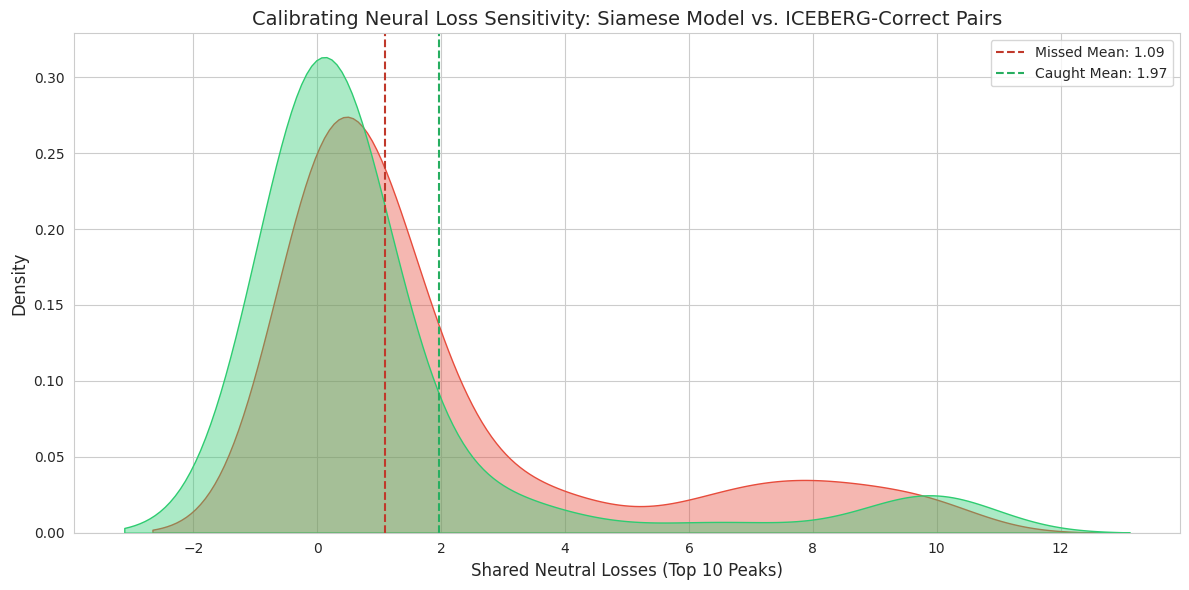

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. CONFIGURATION ---
PATHS = {
    "iceberg": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "siamese": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
}

def get_shared_losses(peaks_a, peaks_b, prec_a, prec_b, top_n=10, tol=0.01):
    """Calculates shared neutral losses between two spectra."""
    if not isinstance(peaks_a, list) or not isinstance(peaks_b, list): return 0
    
    # Calculate relative losses (Precursor - Fragment)
    losses_a = sorted([(prec_a - p[0], p[1]) for p in peaks_a if p[0] < prec_a], 
                      key=lambda x: x[1], reverse=True)[:top_n]
    losses_b = sorted([(prec_b - p[0], p[1]) for p in peaks_b if p[0] < prec_b], 
                      key=lambda x: x[1], reverse=True)[:top_n]
    
    shared = 0
    for l_a, _ in losses_a:
        for l_b, _ in losses_b:
            if abs(l_a - l_b) <= tol:
                shared += 1
                break 
    return shared

# --- 2. LOAD DATA ---
print("Loading data files...")
df_ice = pd.read_csv(PATHS["iceberg"])
df_sia = pd.read_csv(PATHS["siamese"])
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# --- 3. DEFINE GLOBAL RISK & STATUS ---
print("Establishing 5% Global Risk threshold...")
TOTAL_NEG = (df_sia['true_label'] == 0).sum()
ERROR_BUDGET = int(TOTAL_NEG * 0.05)

# Identify ICEBERG's Confident Correct zone (The benchmark)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()

# We only care about True Positives that ICEBERG found at 5% risk
ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= ERROR_BUDGET) & (df_ice_sorted['true_label'] == 1)].copy()

# Merge with Siamese to check performance
merged = pd.merge(
    ice_tp_zone[['name_main', 'name_sub', 'cosine_similarity']],
    df_sia[['name_main', 'name_sub', 'prob_similarity', 'true_label']],
    on=['name_main', 'name_sub']
)

# Label: Caught (Sia >= 0.5) vs Missed (Sia < 0.5)
merged['status'] = np.where(merged['prob_similarity'] >= 0.5, 'Caught', 'Missed')

# --- 4. ENRICH WITH SPECTRAL DATA & CALCULATE LOSSES ---
print("Enriching pairs with metadata and calculating shared losses...")
def enrich_row(row):
    try:
        s1, s2 = spec_lookup.loc[row['name_main']], spec_lookup.loc[row['name_sub']]
        return get_shared_losses(s1['peaks'], s2['peaks'], s1['prec_mz'], s2['prec_mz'])
    except: return 0

merged['shared_loss_count'] = merged.apply(enrich_row, axis=1)

# --- 5. STATISTICAL ANALYSIS ---
caught_losses = merged[merged['status'] == 'Caught']['shared_loss_count']
missed_losses = merged[merged['status'] == 'Missed']['shared_loss_count']

t_stat, p_val = stats.ttest_ind(caught_losses, missed_losses)

print("\n" + "="*40)
print(f"RESULTS SUMMARY (N={len(merged)})")
print("="*40)
print(f"Avg Shared Losses (Caught): {caught_losses.mean():.3f}")
print(f"Avg Shared Losses (Missed): {missed_losses.mean():.3f}")
print(f"T-Statistic: {t_stat:.4f} | P-Value: {p_val:.4e}")

# --- 6. VISUALIZATION ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create a normalized distribution plot
sns.kdeplot(data=merged, x='shared_loss_count', hue='status', 
            fill=True, common_norm=False, palette=['#2ecc71', '#e74c3c'], alpha=.4)

plt.title('Calibrating Neural Loss Sensitivity: Siamese Model vs. ICEBERG-Correct Pairs', fontsize=14)
plt.xlabel('Shared Neutral Losses (Top 10 Peaks)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.axvline(missed_losses.mean(), color='#c0392b', linestyle='--', label=f'Missed Mean: {missed_losses.mean():.2f}')
plt.axvline(caught_losses.mean(), color='#27ae60', linestyle='--', label=f'Caught Mean: {caught_losses.mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('neural_loss_diagnostic.png')
plt.show()

# Export for inspection
merged.to_csv("siamese_vs_iceberg_loss_diagnostic.csv", index=False)

Loading data...
Filtering for ICEBERG True Positives in the 5% Risk Zone...
Enriching metadata and calculating metrics...

ANALYTICAL RESULTS (N=441)

Metric: Shared Anchors
Avg (Caught): 3.2819
Avg (Missed): 2.8654
T-Stat: 3.1595 | P-Value: 1.6896e-03

Metric: Intensity Skew
Avg (Caught): 0.5342
Avg (Missed): 0.6070
T-Stat: -2.4457 | P-Value: 1.4847e-02


/tmp/ipykernel_2619556/838758013.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='status', y='shared_anchors', palette=['#2ecc71', '#e74c3c'], ax=ax1)


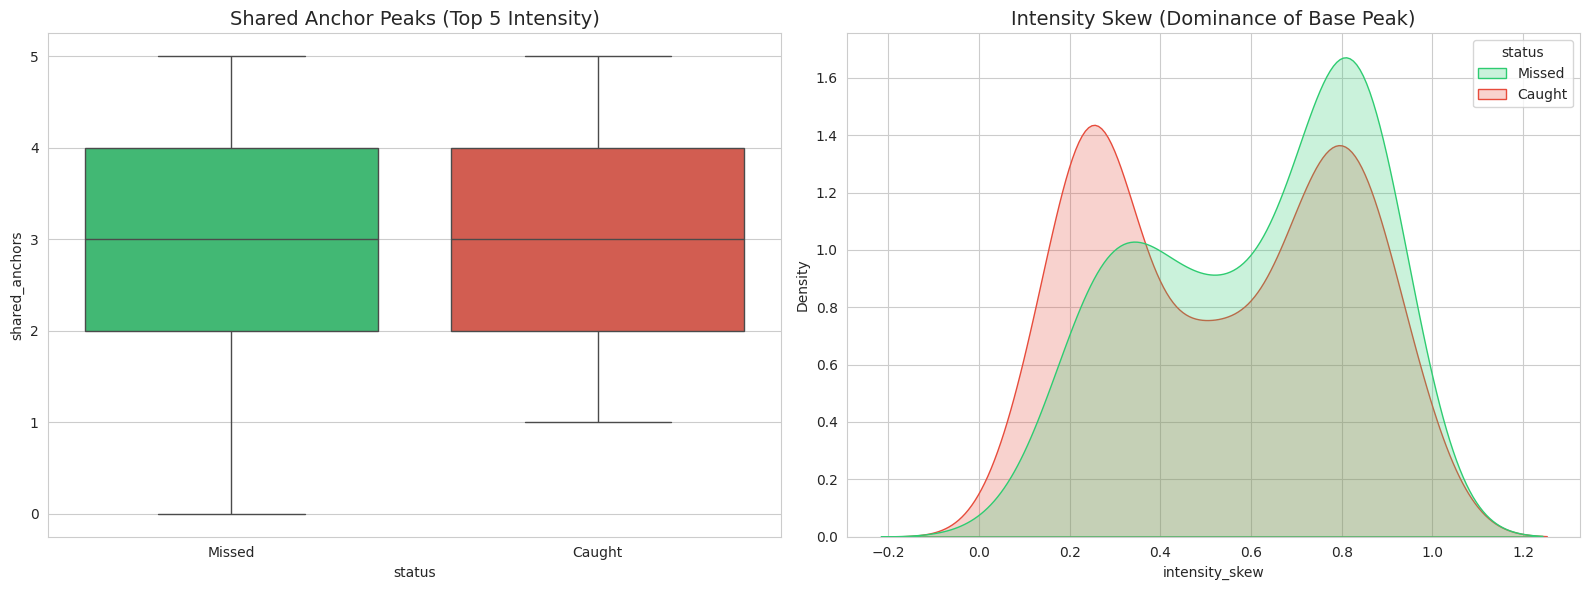

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. CONFIGURATION ---
# Use the paths from your local environment
ICEBERG_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIAMESE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv"
SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

def analyze_anchor_and_skew(peaks_a, peaks_b, top_n=5, tol=0.01):
    """Calculates shared anchors and intensity dominance (skew)."""
    if not isinstance(peaks_a, list) or not isinstance(peaks_b, list) or len(peaks_a) == 0:
        return 0, 0.0
    
    # Anchor Peaks: Overlap in the Top 5 most intense peaks
    top_a = sorted(peaks_a, key=lambda x: x[1], reverse=True)[:top_n]
    top_b = sorted(peaks_b, key=lambda x: x[1], reverse=True)[:top_n]
    
    shared_anchors = 0
    for mz_a, _ in top_a:
        for mz_b, _ in top_b:
            if abs(mz_a - mz_b) <= tol:
                shared_anchors += 1
                break
                
    # Intensity Skew (Dominance): Ratio of Base Peak to Total Intensity
    skew_a = max([p[1] for p in peaks_a]) / sum([p[1] for p in peaks_a])
    skew_b = max([p[1] for p in peaks_b]) / sum([p[1] for p in peaks_b])
    avg_skew = (skew_a + skew_b) / 2
    
    return shared_anchors, avg_skew

# --- 2. LOAD DATA ---
print("Loading data...")
df_ice = pd.read_csv(ICEBERG_PATH)
df_sia = pd.read_csv(SIAMESE_PATH)
spec_lookup = pd.read_pickle(SPEC_DATA_PATH).set_index('spec_id')

# --- 3. FILTER FOR GLOBAL 5% RISK TPs ---
print("Filtering for ICEBERG True Positives in the 5% Risk Zone...")
TOTAL_NEG = (df_sia['true_label'] == 0).sum()
ERROR_BUDGET = int(TOTAL_NEG * 0.05)

df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()

# Target: Pairs where ICEBERG was Confident & Correct
ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= ERROR_BUDGET) & (df_ice_sorted['true_label'] == 1)].copy()

merged = pd.merge(
    ice_tp_zone[['name_main', 'name_sub', 'cosine_similarity']],
    df_sia[['name_main', 'name_sub', 'prob_similarity']],
    on=['name_main', 'name_sub']
)

# Label: Caught (Sia >= 0.5) vs Missed (Sia < 0.5)
merged['status'] = np.where(merged['prob_similarity'] >= 0.5, 'Caught', 'Missed')

# --- 4. CALCULATE METRICS ---
print("Enriching metadata and calculating metrics...")
def enrich_row(row):
    try:
        s1, s2 = spec_lookup.loc[row['name_main']], spec_lookup.loc[row['name_sub']]
        anchors, skew = analyze_anchor_and_skew(s1['peaks'], s2['peaks'])
        return pd.Series({'shared_anchors': anchors, 'intensity_skew': skew})
    except:
        return pd.Series({'shared_anchors': 0, 'intensity_skew': 0.0})

merged[['shared_anchors', 'intensity_skew']] = merged.apply(enrich_row, axis=1)

# --- 5. STATISTICAL SUMMARY ---
print("\n" + "="*45)
print(f"ANALYTICAL RESULTS (N={len(merged)})")
print("="*45)

for metric in ['shared_anchors', 'intensity_skew']:
    caught = merged[merged['status'] == 'Caught'][metric]
    missed = merged[merged['status'] == 'Missed'][metric]
    t_stat, p_val = stats.ttest_ind(caught, missed)
    print(f"\nMetric: {metric.replace('_', ' ').title()}")
    print(f"Avg (Caught): {caught.mean():.4f}")
    print(f"Avg (Missed): {missed.mean():.4f}")
    print(f"T-Stat: {t_stat:.4f} | P-Value: {p_val:.4e}")

# --- 6. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

sns.boxplot(data=merged, x='status', y='shared_anchors', palette=['#2ecc71', '#e74c3c'], ax=ax1)
ax1.set_title('Shared Anchor Peaks (Top 5 Intensity)', fontsize=14)

sns.kdeplot(data=merged, x='intensity_skew', hue='status', fill=True, 
            common_norm=False, palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title('Intensity Skew (Dominance of Base Peak)', fontsize=14)

plt.tight_layout()
plt.savefig('anchor_skew_analysis.png')
plt.show()

merged.to_csv("anchor_skew_diagnostic_results.csv", index=False)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_diagnostic_misses(ice_path, sia_path, spec_path, num_plots=5):
    """
    Generates mirror plots for the top 5 diagnostic misses.
    Highlights the top 5 anchor peaks in each spectrum.
    """
    # 1. LOAD DATA
    print("Loading datasets...")
    df_ice = pd.read_csv(ice_path)
    df_sia = pd.read_csv(sia_path)
    spec_df = pd.read_pickle(spec_path).set_index('spec_id')

    # 2. IDENTIFY TOP 5 MISSES (TRUST GAP)
    # Define Global Risk Threshold (5% FPR)
    total_neg = (df_sia['true_label'] == 0).sum()
    error_budget = int(total_neg * 0.05)

    df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
    df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
    df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
    df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()

    # ICEBERG's Confident Correct zone
    ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= error_budget) & (df_ice_sorted['true_label'] == 1)].copy()

    # Merge to compare with Siamese
    merged = pd.merge(
        ice_tp_zone[['name_main', 'name_sub', 'cosine_similarity']],
        df_sia[['name_main', 'name_sub', 'prob_similarity', 'true_label']],
        on=['name_main', 'name_sub']
    )

    # Filter for significant misses (Siamese predicted < 0.5)
    merged['trust_gap'] = merged['cosine_similarity'] - merged['prob_similarity']
    top_misses = merged[merged['prob_similarity'] < 0.5].sort_values('trust_gap', ascending=False).head(num_plots)

    if top_misses.empty:
        print("No diagnostic misses found in the confident zone.")
        return

    # 3. GENERATE VISUALIZATIONS
    print(f"Generating {len(top_misses)} mirror plots...")
    for i, (idx, row) in enumerate(top_misses.iterrows()):
        peaks_main = sorted(spec_df.loc[row['name_main']]['peaks'], key=lambda x: x[0])
        peaks_sub = sorted(spec_df.loc[row['name_sub']]['peaks'], key=lambda x: x[0])

        # Identify Top 5 Anchor Peaks (Intensity)
        top_main = sorted(peaks_main, key=lambda x: x[1], reverse=True)[:5]
        top_sub = sorted(peaks_sub, key=lambda x: x[1], reverse=True)[:5]
        mz_anchors_main = [p[0] for p in top_main]
        mz_anchors_sub = [p[0] for p in top_sub]

        # Plot Construction
        fig, ax = plt.subplots(figsize=(14, 8))
        
        main_color, sub_color, neutral = '#2980b9', '#c0392b', '#bdc3c7'
        
        # Plot Main (Top)
        for mz, intensity in peaks_main:
            is_anchor = mz in mz_anchors_main
            color = main_color if is_anchor else neutral
            lw = 2.0 if is_anchor else 0.8
            ax.vlines(mz, 0, intensity, colors=color, linewidth=lw, alpha=0.9 if is_anchor else 0.5)
            if is_anchor:
                ax.text(mz, intensity + 0.01, f"{mz:.2f}", ha='center', va='bottom', 
                        fontsize=10, color=main_color, fontweight='bold', rotation=90)

        # Plot Sub (Bottom)
        for mz, intensity in peaks_sub:
            is_anchor = mz in mz_anchors_sub
            color = sub_color if is_anchor else neutral
            lw = 2.0 if is_anchor else 0.8
            ax.vlines(mz, 0, -intensity, colors=color, linewidth=lw, alpha=0.9 if is_anchor else 0.5)
            if is_anchor:
                ax.text(mz, -intensity - 0.01, f"{mz:.2f}", ha='center', va='top', 
                        fontsize=10, color=sub_color, fontweight='bold', rotation=90)

        # Decorations
        ax.axhline(0, color='black', linewidth=1.5)
        ax.set_ylim(-1.3, 1.3)
        ax.set_xlabel("m/z", fontsize=12)
        ax.set_ylabel("Relative Intensity", fontsize=12)
        ax.set_title(f"Diagnostic Mirror Plot: Miss #{i+1}\nICEBERG Sim: {row['cosine_similarity']:.3f} | Siamese Sim: {row['prob_similarity']:.3f}", 
                     fontsize=15, fontweight='bold', pad=30)
        
        # Legends and Labels
        main_patch = mpatches.Patch(color=main_color, label='Main (ICE Anchors)')
        sub_patch = mpatches.Patch(color=sub_color, label='Sub (Sia Anchors)')
        ax.legend(handles=[main_patch, sub_patch], loc='upper right', frameon=True)
        ax.text(0.01, 0.98, "Main Spectrum (Confident ICE)", transform=ax.transAxes, fontsize=11, color=main_color, verticalalignment='top')
        ax.text(0.01, 0.02, "Sub Spectrum (Siamese Missed)", transform=ax.transAxes, fontsize=11, color=sub_color, verticalalignment='bottom')

        plt.grid(axis='y', linestyle='--', alpha=0.2)
        plt.tight_layout()
        
        # Save results
        out_name = f"mirror_diagnostic_miss_{i+1}.png"
        plt.savefig(out_name, dpi=300)
        plt.close()
        print(f"Saved: {out_name}")

# --- UPDATE PATHS BEFORE RUNNING ---
ICE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv"
SPEC_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

visualize_diagnostic_misses(ICE_PATH, SIA_PATH, SPEC_PATH)

Loading datasets...
Generating 5 mirror plots...
Saved: mirror_diagnostic_miss_1.png
Saved: mirror_diagnostic_miss_2.png
Saved: mirror_diagnostic_miss_3.png
Saved: mirror_diagnostic_miss_4.png
Saved: mirror_diagnostic_miss_5.png


Loading data...


Calculating intensity skew for the test set...
High Skew Threshold: 0.710
Total pairs in High Skew regime: 413

HIGH SKEW REGIME PERFORMANCE COMPARISON
Total True Pairs in Regime: 368
ICEBERG TPs Identified: 125
Siamese TPs Identified: 112
Discovery Gap: 13 pairs


/tmp/ipykernel_2619556/2532311803.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=yields, palette=['#3498db', '#e67e22'])


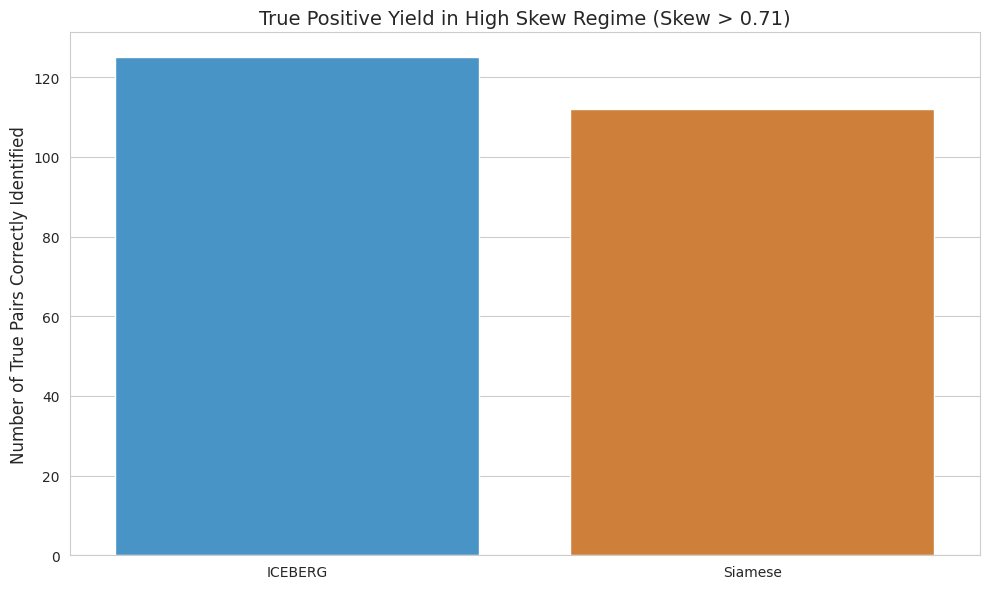

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION ---
PATHS = {
    "iceberg": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "siamese": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

def get_intensity_skew(peaks):
    """Calculates the dominance of the base peak."""
    if not isinstance(peaks, list) or len(peaks) == 0: return 0.0
    intensities = [p[1] for p in peaks]
    return max(intensities) / sum(intensities)

# --- 2. LOAD & ENRICH DATA ---
print("Loading data...")
df_ice = pd.read_csv(PATHS["iceberg"])
df_sia = pd.read_csv(PATHS["siamese"])
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Calculate Skew for all pairs in the Siamese test set
print("Calculating intensity skew for the test set...")
def calc_pair_skew(row):
    try:
        s1 = spec_lookup.loc[row['name_main']]
        s2 = spec_lookup.loc[row['name_sub']]
        return (get_intensity_skew(s1['peaks']) + get_intensity_skew(s2['peaks'])) / 2
    except: return 0.0

df_sia['avg_skew'] = df_sia.apply(calc_pair_skew, axis=1)

# --- 3. DEFINE "HIGH SKEW" REGIME ---
# We define High Skew as the top 25% of the most skewed spectra
SKEW_THRESHOLD = df_sia['avg_skew'].quantile(0.75)
high_skew_df = df_sia[df_sia['avg_skew'] >= SKEW_THRESHOLD].copy()

print(f"High Skew Threshold: {SKEW_THRESHOLD:.3f}")
print(f"Total pairs in High Skew regime: {len(high_skew_df)}")

# --- 4. COMPARE TRUE POSITIVE YIELD AT 5% GLOBAL RISK ---
# Align ICEBERG scores to this subset
merged_high_skew = pd.merge(
    high_skew_df[['name_main', 'name_sub', 'true_label', 'prob_similarity', 'avg_skew']],
    df_ice[['name_main', 'name_sub', 'cosine_similarity']],
    on=['name_main', 'name_sub']
)

# Constant Risk Thresholds (from previous 5% global calculation)
# Note: These values (0.352 and 0.256) were derived from your earlier run
ICE_CONF_LIMIT = 0.352 
SIA_CONF_LIMIT = 0.256

# Count TPs identified by each model in the High Skew subset
# A TP is found if it's a true match AND the model is confident
ice_tps = merged_high_skew[(merged_high_skew['true_label'] == 1) & 
                           (merged_high_skew['cosine_similarity'] >= 0.5) & 
                           (np.abs(merged_high_skew['cosine_similarity'] - 0.5) >= ICE_CONF_LIMIT)]

sia_tps = merged_high_skew[(merged_high_skew['true_label'] == 1) & 
                           (merged_high_skew['prob_similarity'] >= 0.5) & 
                           (np.abs(merged_high_skew['prob_similarity'] - 0.5) >= SIA_CONF_LIMIT)]

# --- 5. RESULTS ---
print("\n" + "="*45)
print("HIGH SKEW REGIME PERFORMANCE COMPARISON")
print("="*45)
print(f"Total True Pairs in Regime: {(merged_high_skew['true_label'] == 1).sum()}")
print(f"ICEBERG TPs Identified: {len(ice_tps)}")
print(f"Siamese TPs Identified: {len(sia_tps)}")
print(f"Discovery Gap: {len(ice_tps) - len(sia_tps)} pairs")

# --- 6. VISUALIZATION ---
plt.figure(figsize=(10, 6))
labels = ['ICEBERG', 'Siamese']
yields = [len(ice_tps), len(sia_tps)]

sns.barplot(x=labels, y=yields, palette=['#3498db', '#e67e22'])
plt.title(f'True Positive Yield in High Skew Regime (Skew > {SKEW_THRESHOLD:.2f})', fontsize=14)
plt.ylabel('Number of True Pairs Correctly Identified', fontsize=12)
plt.tight_layout()
plt.savefig('high_skew_yield_comparison.png')
plt.show()

Loading datasets...
Analyzing peak density and sparsity...

SPECTRAL COMPLEXITY DIAGNOSTICS

Metric: Avg Peak Density
Avg (Caught): 21.16 peaks
Avg (Missed): 19.73 peaks
T-Stat: 0.8655 | P-Value: 3.8725e-01

Metric: Peak Count Diff
Avg (Caught): 8.78 peaks
Avg (Missed): 8.97 peaks
T-Stat: -0.1784 | P-Value: 8.5846e-01


/tmp/ipykernel_2619556/431603531.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=merged, x='status', y='avg_peak_density', split=True, inner="quart", palette=['#2ecc71', '#e74c3c'])


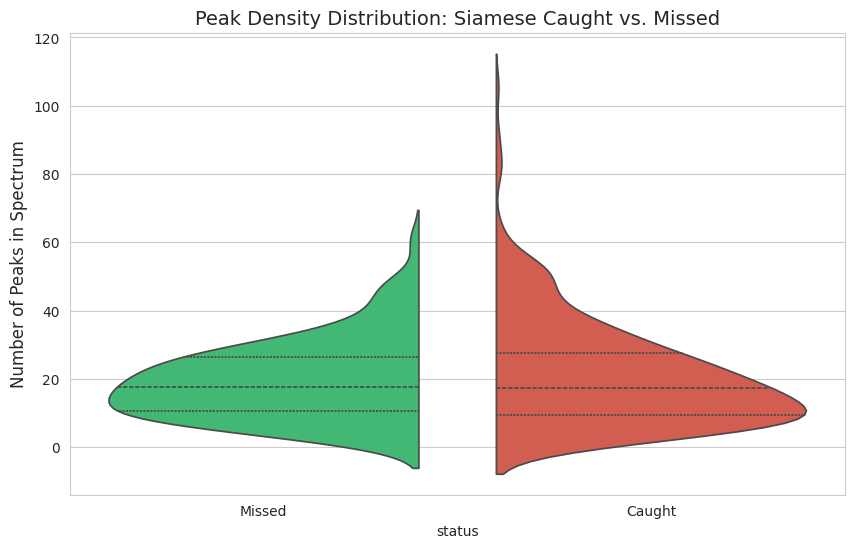

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. CONFIGURATION ---
PATHS = {
    "iceberg": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "siamese": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD & PREPARE DATA ---
print("Loading datasets...")
df_ice = pd.read_csv(PATHS["iceberg"])
df_sia = pd.read_csv(PATHS["siamese"])
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Define Global Risk Baseline (5% FPR)
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)

df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()

# Isolate ICEBERG True Positives
ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= error_budget) & (df_ice_sorted['true_label'] == 1)].copy()

merged = pd.merge(
    ice_tp_zone[['name_main', 'name_sub', 'cosine_similarity']],
    df_sia[['name_main', 'name_sub', 'prob_similarity']],
    on=['name_main', 'name_sub']
)

merged['status'] = np.where(merged['prob_similarity'] >= 0.5, 'Caught', 'Missed')

# --- 3. CALCULATE COMPLEXITY METRICS ---
def get_complexity_metrics(row):
    try:
        s1, s2 = spec_lookup.loc[row['name_main']], spec_lookup.loc[row['name_sub']]
        n1, n2 = len(s1['peaks']), len(s2['peaks'])
        
        return pd.Series({
            'avg_peak_density': (n1 + n2) / 2,
            'peak_count_diff': abs(n1 - n2),
            'sparsity_ratio': min(n1, n2) / max(n1, n2) if max(n1, n2) > 0 else 0
        })
    except:
        return pd.Series({'avg_peak_density': 0, 'peak_count_diff': 0, 'sparsity_ratio': 0})

print("Analyzing peak density and sparsity...")
merged[['avg_peak_density', 'peak_count_diff', 'sparsity_ratio']] = merged.apply(get_complexity_metrics, axis=1)

# --- 4. STATISTICAL ANALYSIS ---
print("\n" + "="*45)
print("SPECTRAL COMPLEXITY DIAGNOSTICS")
print("="*45)

for metric in ['avg_peak_density', 'peak_count_diff']:
    caught = merged[merged['status'] == 'Caught'][metric]
    missed = merged[merged['status'] == 'Missed'][metric]
    t_stat, p_val = stats.ttest_ind(caught, missed)
    print(f"\nMetric: {metric.replace('_', ' ').title()}")
    print(f"Avg (Caught): {caught.mean():.2f} peaks")
    print(f"Avg (Missed): {missed.mean():.2f} peaks")
    print(f"T-Stat: {t_stat:.4f} | P-Value: {p_val:.4e}")

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Violin plot to see the density distribution
sns.violinplot(data=merged, x='status', y='avg_peak_density', split=True, inner="quart", palette=['#2ecc71', '#e74c3c'])
plt.title('Peak Density Distribution: Siamese Caught vs. Missed', fontsize=14)
plt.ylabel('Number of Peaks in Spectrum', fontsize=12)
plt.savefig('peak_density_diagnostic.png')
plt.show()

## Analyzing structural characteristics of the misses

Loading molecular and result data...


Calculating molecular descriptors...

STRUCTURAL RIGIDITY VS FLEXIBILITY DIAGNOSTICS

Metric: Avg Rot Bonds
Avg (Caught): 4.249
Avg (Missed): 5.207
T-Stat: -2.8799 | P-Val: 4.1723e-03

Metric: Avg Arom Rings
Avg (Caught): 2.059
Avg (Missed): 2.409
T-Stat: -3.0514 | P-Val: 2.4158e-03

Metric: Rot Bond Density
Avg (Caught): 1.125
Avg (Missed): 1.431
T-Stat: -3.7344 | P-Val: 2.1298e-04


/tmp/ipykernel_2619556/1984574652.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='status', y='avg_rot_bonds', palette=['#2ecc71', '#e74c3c'], ax=ax1)
/tmp/ipykernel_2619556/1984574652.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='status', y='avg_arom_rings', palette=['#2ecc71', '#e74c3c'], ax=ax2)


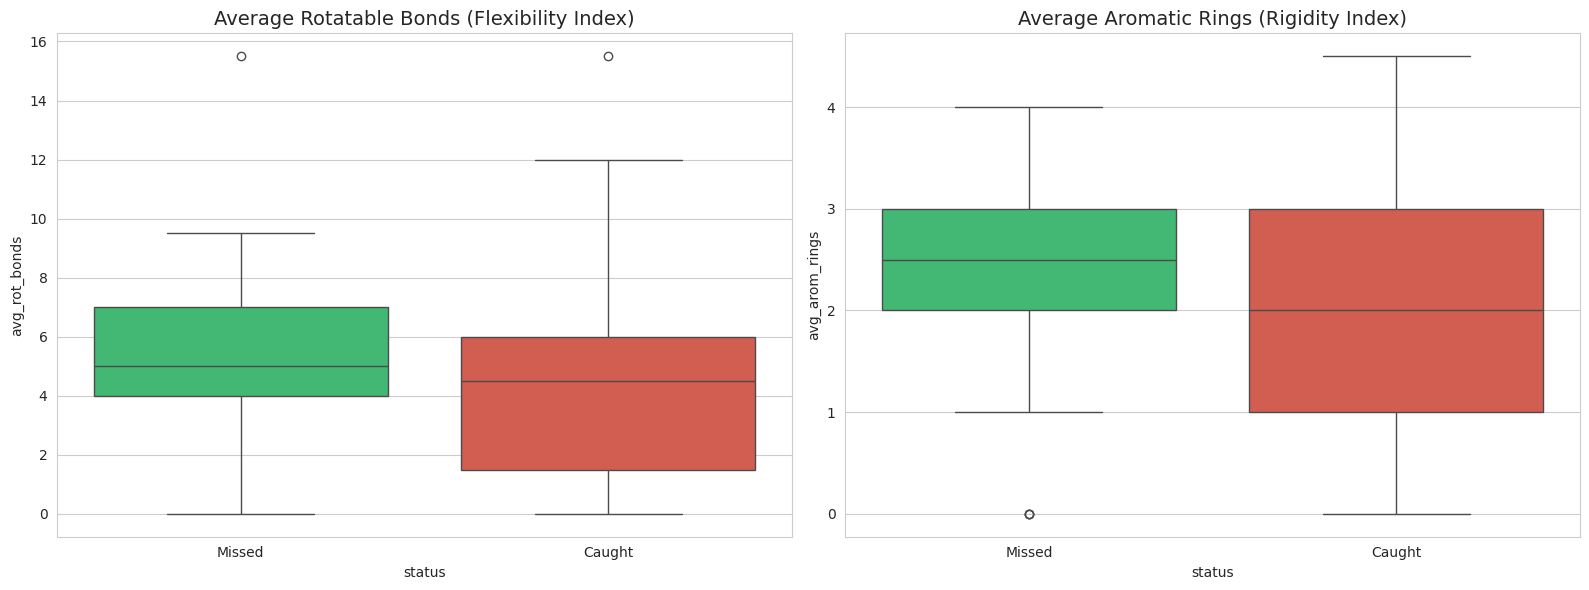

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy import stats

# --- 1. CONFIGURATION ---
PATHS = {
    "iceberg": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "siamese": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD & ALIGN DATA ---
print("Loading molecular and result data...")
df_ice = pd.read_csv(PATHS["iceberg"])
df_sia = pd.read_csv(PATHS["siamese"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Define Global Risk Baseline (5% FPR)
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)

df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()

ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= error_budget) & (df_ice_sorted['true_label'] == 1)].copy()

merged = pd.merge(
    ice_tp_zone[['name_main', 'name_sub', 'cosine_similarity']],
    df_sia[['name_main', 'name_sub', 'prob_similarity']],
    on=['name_main', 'name_sub']
)

merged['status'] = np.where(merged['prob_similarity'] >= 0.5, 'Caught', 'Missed')

# --- 3. CALCULATE STRUCTURAL METRICS ---
def get_structural_metrics(row):
    try:
        # Get mol_ids from spec_lookup
        mol_id_main = spec_lookup.loc[row['name_main']]['mol_id']
        mol_id_sub = spec_lookup.loc[row['name_sub']]['mol_id']
        
        smiles_main = mol_lookup.loc[mol_id_main]['smiles']
        smiles_sub = mol_lookup.loc[mol_id_sub]['smiles']
        
        mols = [Chem.MolFromSmiles(smiles_main), Chem.MolFromSmiles(smiles_sub)]
        
        # Rotatable Bonds (Flexibility)
        rot_bonds = [Descriptors.NumRotatableBonds(m) for m in mols]
        # Aromatic Rings (Rigidity)
        arom_rings = [Descriptors.NumAromaticRings(m) for m in mols]
        # Molecular Weight (Size)
        mws = [Descriptors.MolWt(m) for m in mols]
        
        return pd.Series({
            'avg_rot_bonds': np.mean(rot_bonds),
            'avg_arom_rings': np.mean(arom_rings),
            'avg_mw': np.mean(mws),
            'rot_bond_density': np.mean(rot_bonds) / np.mean(mws) * 100 # Normalized flexibility
        })
    except:
        return pd.Series({'avg_rot_bonds': 0, 'avg_arom_rings': 0, 'avg_mw': 0, 'rot_bond_density': 0})

print("Calculating molecular descriptors...")
merged[['avg_rot_bonds', 'avg_arom_rings', 'avg_mw', 'rot_bond_density']] = merged.apply(get_structural_metrics, axis=1)

# --- 4. STATISTICAL SUMMARY ---
print("\n" + "="*45)
print("STRUCTURAL RIGIDITY VS FLEXIBILITY DIAGNOSTICS")
print("="*45)

for metric in ['avg_rot_bonds', 'avg_arom_rings', 'rot_bond_density']:
    caught = merged[merged['status'] == 'Caught'][metric]
    missed = merged[merged['status'] == 'Missed'][metric]
    t_stat, p_val = stats.ttest_ind(caught, missed)
    print(f"\nMetric: {metric.replace('_', ' ').title()}")
    print(f"Avg (Caught): {caught.mean():.3f}")
    print(f"Avg (Missed): {missed.mean():.3f}")
    print(f"T-Stat: {t_stat:.4f} | P-Val: {p_val:.4e}")

# --- 5. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=merged, x='status', y='avg_rot_bonds', palette=['#2ecc71', '#e74c3c'], ax=ax1)
ax1.set_title('Average Rotatable Bonds (Flexibility Index)', fontsize=14)

sns.boxplot(data=merged, x='status', y='avg_arom_rings', palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title('Average Aromatic Rings (Rigidity Index)', fontsize=14)

plt.tight_layout()
plt.savefig('structural_rigidity_diagnostic.png')
plt.show()

Calculating aromatic counts...


/tmp/ipykernel_2619556/44238987.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x='ring_bin', y='failure_rate', palette='viridis', order=['0', '1', '2', '3', '4+'])


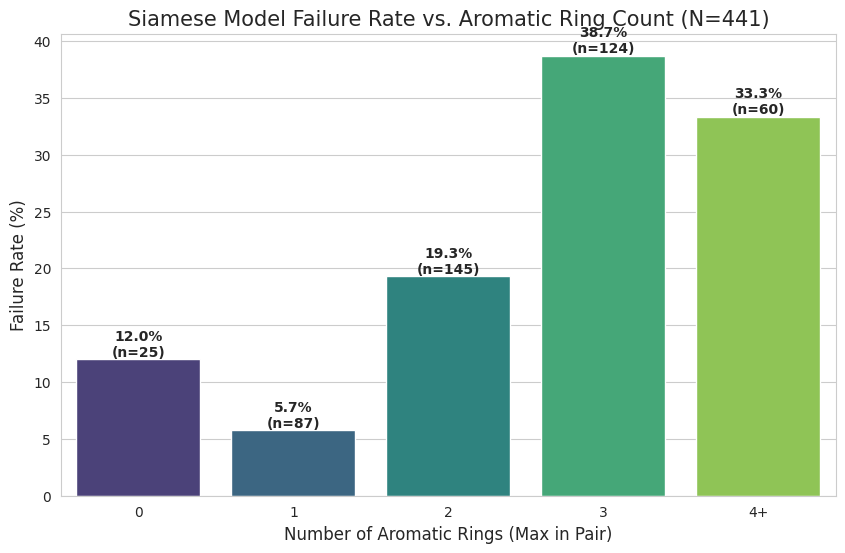

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors

# --- 1. SET YOUR PATHS ---
ICE_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv"
SIA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv"
MOL_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
SPEC_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

# --- 2. LOAD DATA ---
df_ice = pd.read_csv(ICE_PATH)
df_sia = pd.read_csv(SIA_PATH)
mol_lookup = pd.read_pickle(MOL_PATH).set_index('mol_id')
spec_lookup = pd.read_pickle(SPEC_PATH).set_index('spec_id')

# --- 3. IDENTIFY ICEBERG TP ZONE (5% GLOBAL RISK) ---
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()
ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= error_budget) & (df_ice_sorted['true_label'] == 1)].copy()

# Merge with Siamese
merged = pd.merge(
    ice_tp_zone[['name_main', 'name_sub']],
    df_sia[['name_main', 'name_sub', 'prob_similarity']],
    on=['name_main', 'name_sub']
)

# --- 4. CALCULATE AROMATICITY ---
def get_max_rings(row):
    try:
        m_id = spec_lookup.loc[row['name_main']]['mol_id']
        s_id = spec_lookup.loc[row['name_sub']]['mol_id']
        m1 = Chem.MolFromSmiles(mol_lookup.loc[m_id]['smiles'])
        m2 = Chem.MolFromSmiles(mol_lookup.loc[s_id]['smiles'])
        return max(Descriptors.NumAromaticRings(m1), Descriptors.NumAromaticRings(m2))
    except: return np.nan

print("Calculating aromatic counts...")
merged['max_rings'] = merged.apply(get_max_rings, axis=1)
merged = merged.dropna(subset=['max_rings'])

# Binning
merged['ring_bin'] = merged['max_rings'].apply(lambda x: '4+' if x >= 4 else str(int(x)))
merged['is_miss'] = (merged['prob_similarity'] < 0.5).astype(int)

# --- 5. AGGREGATE RESULTS ---
summary = merged.groupby('ring_bin').agg(
    total_pairs=('is_miss', 'count'),
    missed_pairs=('is_miss', 'sum')
).reset_index()
summary['failure_rate'] = (summary['missed_pairs'] / summary['total_pairs']) * 100

# --- 6. PLOT ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=summary, x='ring_bin', y='failure_rate', palette='viridis', order=['0', '1', '2', '3', '4+'])

for i, p in enumerate(ax.patches):
    count = int(summary.iloc[i]['total_pairs'])
    ax.annotate(f'{p.get_height():.1f}%\n(n={count})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Siamese Model Failure Rate vs. Aromatic Ring Count (N=441)', fontsize=15)
plt.xlabel('Number of Aromatic Rings (Max in Pair)', fontsize=12)
plt.ylabel('Failure Rate (%)', fontsize=12)
plt.savefig('aromatic_failure_trend.png')
plt.show()

Loading data...


Calculating aromatic rings and normalising groups...


/tmp/ipykernel_2619556/3127820939.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=norm_summary, x='ring_bin', y='failure_rate', order=order, palette='magma')


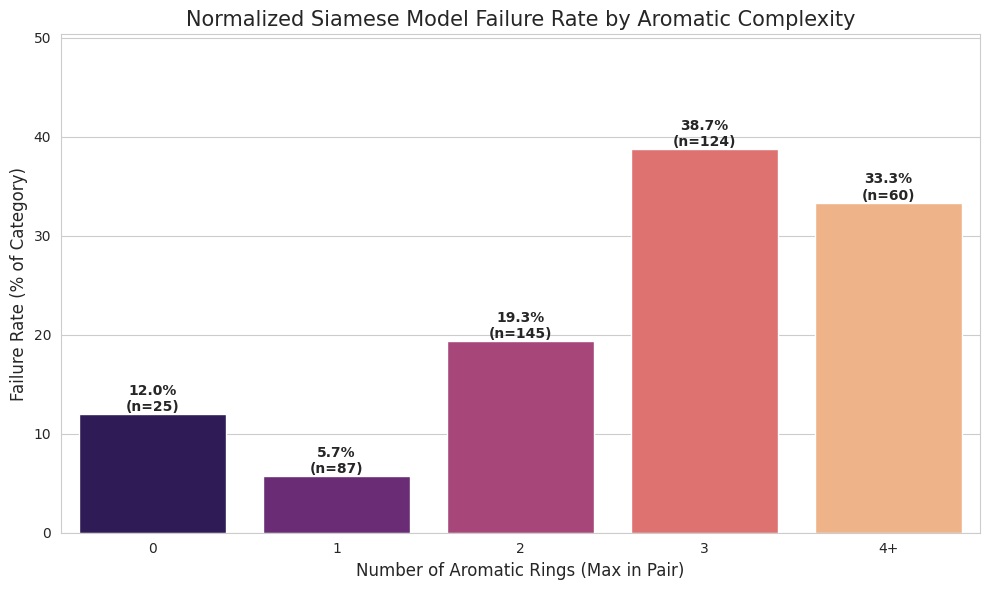


--- Normalized Failure Statistics ---
  ring_bin  total_in_bin  misses_in_bin  failure_rate
0        0            25              3     12.000000
1        1            87              5      5.747126
2        2           145             28     19.310345
3        3           124             48     38.709677
4       4+            60             20     33.333333


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors

# --- 1. CONFIGURATION ---
PATHS = {
    "iceberg": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "siamese": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD & ALIGN DATA ---
print("Loading data...")
df_ice = pd.read_csv(PATHS["iceberg"])
df_sia = pd.read_csv(PATHS["siamese"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Re-establish Benchmark Zone (5% Global Risk)
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()
ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= error_budget) & (df_ice_sorted['true_label'] == 1)].copy()

merged = pd.merge(ice_tp_zone[['name_main', 'name_sub']], 
                  df_sia[['name_main', 'name_sub', 'prob_similarity']], on=['name_main', 'name_sub'])

# --- 3. CALCULATE NORMALIZED AROMATICITY ---
print("Calculating aromatic rings and normalising groups...")
def get_rings(row):
    try:
        m1 = Chem.MolFromSmiles(mol_lookup.loc[spec_lookup.loc[row['name_main']]['mol_id']]['smiles'])
        m2 = Chem.MolFromSmiles(mol_lookup.loc[spec_lookup.loc[row['name_sub']]['mol_id']]['smiles'])
        return max(Descriptors.NumAromaticRings(m1), Descriptors.NumAromaticRings(m2))
    except: return np.nan

merged['arom_rings'] = merged.apply(get_rings, axis=1)
merged = merged.dropna(subset=['arom_rings'])

# Binning
merged['ring_bin'] = merged['arom_rings'].apply(lambda x: '4+' if x >= 4 else str(int(x)))
merged['is_miss'] = (merged['prob_similarity'] < 0.5).astype(int)

# --- 4. AGGREGATE NORMALIZED FAILURE RATES ---
norm_summary = merged.groupby('ring_bin').agg(
    total_in_bin=('is_miss', 'count'),
    misses_in_bin=('is_miss', 'sum')
).reset_index()

# Normalization Step: (Misses / Total in that Bin) * 100
norm_summary['failure_rate'] = (norm_summary['misses_in_bin'] / norm_summary['total_in_bin']) * 100

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
# Sort bins correctly
order = ['0', '1', '2', '3', '4+']
ax = sns.barplot(data=norm_summary, x='ring_bin', y='failure_rate', order=order, palette='magma')

# Add "n=" counts and percentage labels on top of bars
for i, p in enumerate(ax.patches):
    bin_label = order[i]
    row = norm_summary[norm_summary['ring_bin'] == bin_label].iloc[0]
    ax.annotate(f"{row['failure_rate']:.1f}%\n(n={int(row['total_in_bin'])})", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Normalized Siamese Model Failure Rate by Aromatic Complexity', fontsize=15)
plt.ylabel('Failure Rate (% of Category)', fontsize=12)
plt.xlabel('Number of Aromatic Rings (Max in Pair)', fontsize=12)
plt.ylim(0, max(norm_summary['failure_rate']) * 1.3)
plt.tight_layout()
plt.savefig('normalized_aromatic_failure.png')
plt.show()

print("\n--- Normalized Failure Statistics ---")
print(norm_summary)

Analyzing heterocyclic vs pure carbon systems...


/tmp/ipykernel_2619556/1408561798.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=summary, x='ring_type', y='failure_rate', palette='coolwarm')


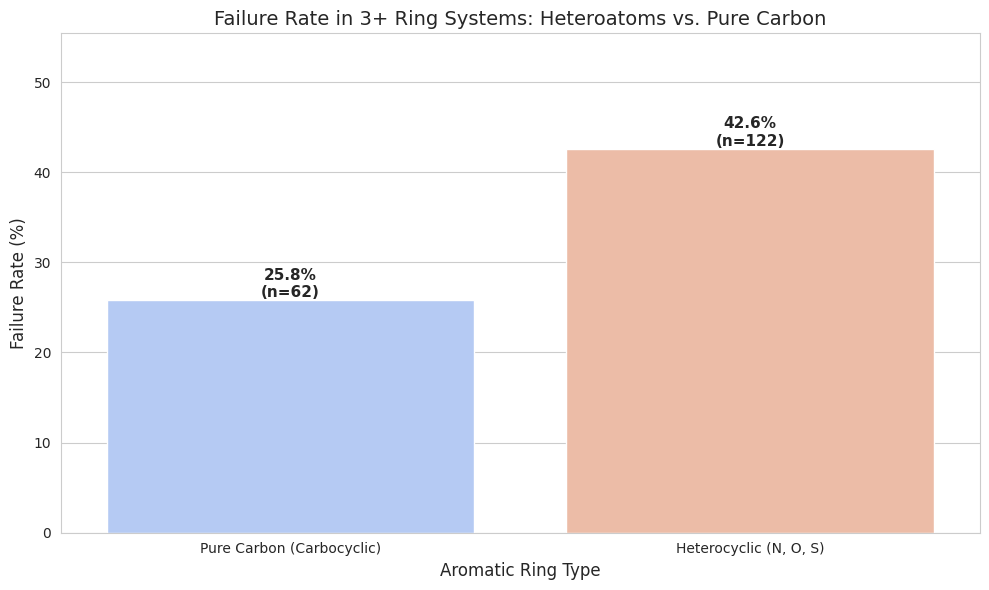


--- Detailed Breakdown for 3+ Rings ---
                   ring_type  total_pairs  misses  failure_rate
0  Pure Carbon (Carbocyclic)           62      16     25.806452
1     Heterocyclic (N, O, S)          122      52     42.622951


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors

# --- 1. CONFIGURATION ---
PATHS = {
    "iceberg": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "siamese": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD & ALIGN DATA ---
df_ice = pd.read_csv(PATHS["iceberg"])
df_sia = pd.read_csv(PATHS["siamese"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Benchmark zone: ICEBERG TPs at 5% Risk
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()
ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= error_budget) & (df_ice_sorted['true_label'] == 1)].copy()

merged = pd.merge(ice_tp_zone[['name_main', 'name_sub']], 
                  df_sia[['name_main', 'name_sub', 'prob_similarity']], on=['name_main', 'name_sub'])

# --- 3. FILTER FOR 3+ RING "DANGER ZONE" ---
def get_ring_info(row):
    try:
        s1 = mol_lookup.loc[spec_lookup.loc[row['name_main']]['mol_id']]['smiles']
        s2 = mol_lookup.loc[spec_lookup.loc[row['name_sub']]['mol_id']]['smiles']
        mols = [Chem.MolFromSmiles(s1), Chem.MolFromSmiles(s2)]
        
        max_rings = max([Descriptors.NumAromaticRings(m) for m in mols])
        
        # Check for Heteroatoms in Aromatic Rings
        # 
        has_hetero = False
        for m in mols:
            for ring in m.GetRingInfo().AtomRings():
                if any(m.GetAtomWithIdx(i).GetSymbol() not in ['C', 'H'] for i in ring):
                    # Check if this specific ring is aromatic
                    if all(m.GetAtomWithIdx(i).GetIsAromatic() for i in ring):
                        has_hetero = True
                        break
        
        return pd.Series({'max_rings': max_rings, 'is_heterocyclic': has_hetero})
    except:
        return pd.Series({'max_rings': 0, 'is_heterocyclic': False})

print("Analyzing heterocyclic vs pure carbon systems...")
merged[['max_rings', 'is_heterocyclic']] = merged.apply(get_ring_info, axis=1)

# Keep only the 3+ ring pairs
danger_zone = merged[merged['max_rings'] >= 3].copy()
danger_zone['is_miss'] = (danger_zone['prob_similarity'] < 0.5).astype(int)

# --- 4. AGGREGATE RESULTS ---
summary = danger_zone.groupby('is_heterocyclic').agg(
    total_pairs=('is_miss', 'count'),
    misses=('is_miss', 'sum')
).reset_index()

summary['failure_rate'] = (summary['misses'] / summary['total_pairs']) * 100
summary['ring_type'] = summary['is_heterocyclic'].map({True: 'Heterocyclic (N, O, S)', False: 'Pure Carbon (Carbocyclic)'})

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=summary, x='ring_type', y='failure_rate', palette='coolwarm')

for i, p in enumerate(ax.patches):
    count = int(summary.iloc[i]['total_pairs'])
    ax.annotate(f"{p.get_height():.1f}%\n(n={count})", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Failure Rate in 3+ Ring Systems: Heteroatoms vs. Pure Carbon', fontsize=14)
plt.ylabel('Failure Rate (%)', fontsize=12)
plt.xlabel('Aromatic Ring Type', fontsize=12)
plt.ylim(0, max(summary['failure_rate']) * 1.3)
plt.tight_layout()
plt.savefig('hetero_vs_carbocyclic_failure.png')
plt.show()

print("\n--- Detailed Breakdown for 3+ Rings ---")
print(summary[['ring_type', 'total_pairs', 'misses', 'failure_rate']])

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors

# --- 1. CONFIGURATION ---
PATHS = {
    "iceberg": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "siamese": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD & ALIGN DATA ---
df_ice = pd.read_csv(PATHS["iceberg"])
df_sia = pd.read_csv(PATHS["siamese"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Benchmark zone: ICEBERG TPs at 5% Risk
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()
ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= error_budget) & (df_ice_sorted['true_label'] == 1)].copy()

merged = pd.merge(ice_tp_zone[['name_main', 'name_sub']], 
                  df_sia[['name_main', 'name_sub', 'prob_similarity']], on=['name_main', 'name_sub'])

# --- 3. CALCULATE PAIR-WISE RING METRICS ---
def analyze_pair_rings(row):
    try:
        m1_id = spec_lookup.loc[row['name_main']]['mol_id']
        m2_id = spec_lookup.loc[row['name_sub']]['mol_id']
        sm1, sm2 = mol_lookup.loc[m1_id]['smiles'], mol_lookup.loc[m2_id]['smiles']
        r1 = Descriptors.NumAromaticRings(Chem.MolFromSmiles(sm1))
        r2 = Descriptors.NumAromaticRings(Chem.MolFromSmiles(sm2))
        
        return pd.Series({
            'min_rings': min(r1, r2),
            'max_rings': max(r1, r2),
            'ring_diff': abs(r1 - r2),
            'is_both_heavy': 1 if (r1 >= 3 and r2 >= 3) else 0
        })
    except:
        return pd.Series({'min_rings': 0, 'max_rings': 0, 'ring_diff': 0, 'is_both_heavy': 0})

print("Analyzing pair-wise ring distributions...")
merged[['min_rings', 'max_rings', 'ring_diff', 'is_both_heavy']] = merged.apply(analyze_pair_rings, axis=1)
merged['status'] = np.where(merged['prob_similarity'] >= 0.5, 'Caught', 'Missed')

# --- 4. STATISTICAL COMPARISON ---
print("\n" + "="*45)
print("PAIR-WISE RING SYMMETRY DIAGNOSTICS")
print("="*45)

for metric in ['ring_diff', 'min_rings', 'max_rings']:
    caught = merged[merged['status'] == 'Caught'][metric]
    missed = merged[merged['status'] == 'Missed'][metric]
    from scipy import stats
    t_stat, p_val = stats.ttest_ind(caught, missed)
    print(f"\nMetric: {metric.replace('_', ' ').title()}")
    print(f"Avg (Caught): {caught.mean():.2f}")
    print(f"Avg (Missed): {missed.mean():.2f}")
    print(f"P-Value: {p_val:.4e}")

# --- 5. HEAVY PAIR ANALYSIS ---
heavy_stats = merged.groupby(['is_both_heavy', 'status']).size().unstack(fill_value=0)
print("\n--- Heavy Pair (Both 3+ Rings) vs. Normal ---")
print(heavy_stats)

Analyzing pair-wise ring distributions...

PAIR-WISE RING SYMMETRY DIAGNOSTICS

Metric: Ring Diff
Avg (Caught): 0.08
Avg (Missed): 0.66
P-Value: 4.4737e-22

Metric: Min Rings
Avg (Caught): 2.02
Avg (Missed): 2.08
P-Value: 6.2740e-01

Metric: Max Rings
Avg (Caught): 2.10
Avg (Missed): 2.74
P-Value: 1.5254e-07

--- Heavy Pair (Both 3+ Rings) vs. Normal ---
status         Caught  Missed
is_both_heavy                
0                 232      66
1                 105      38


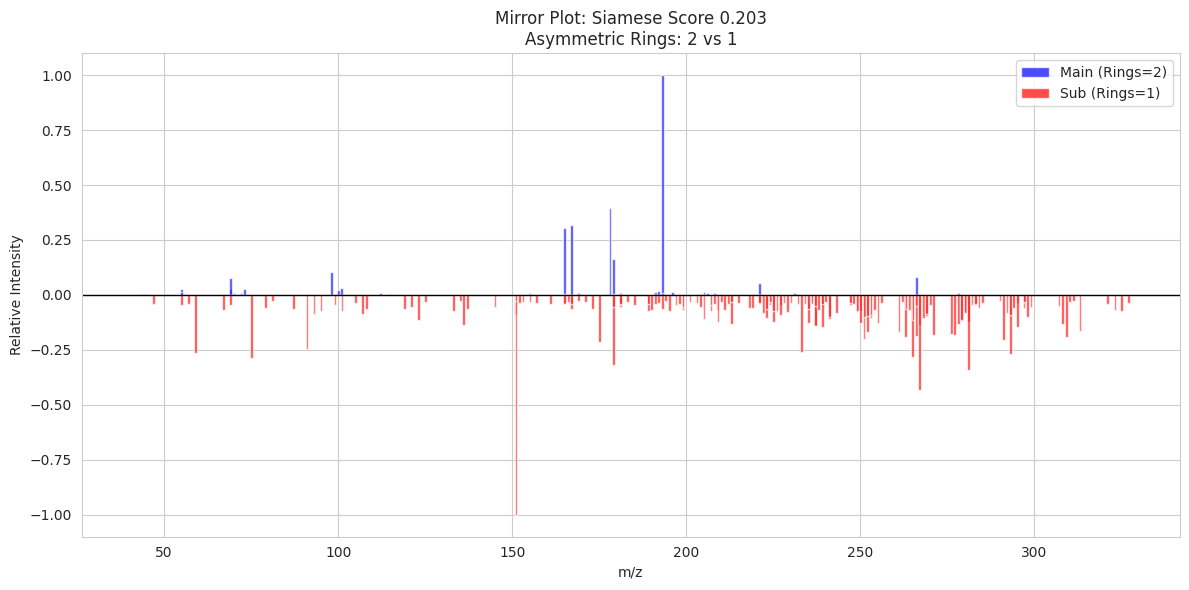

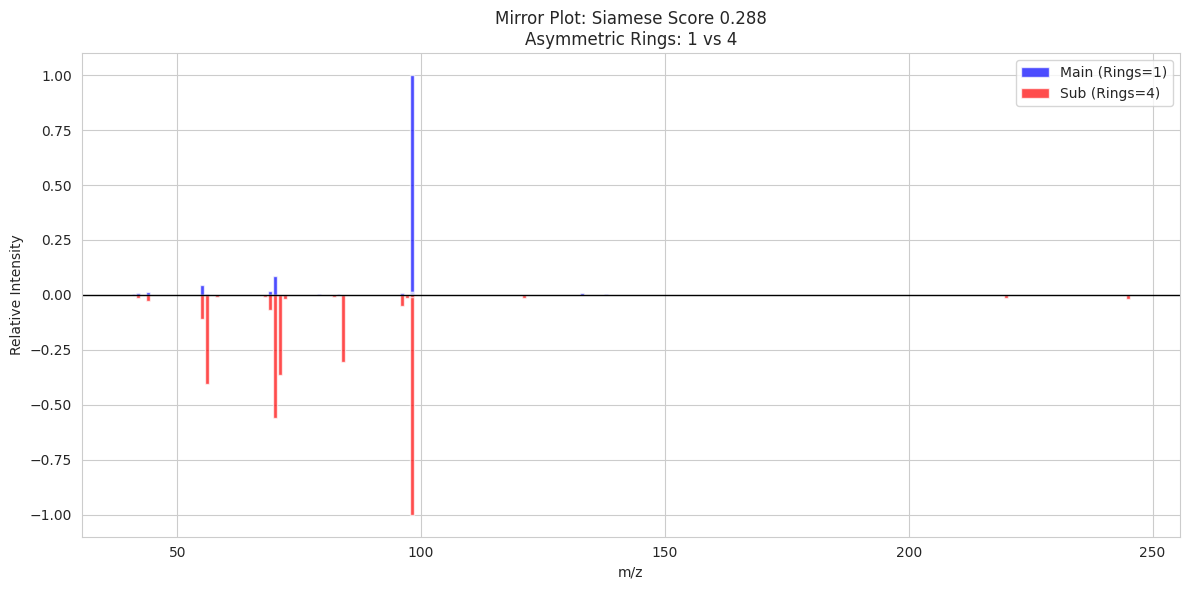

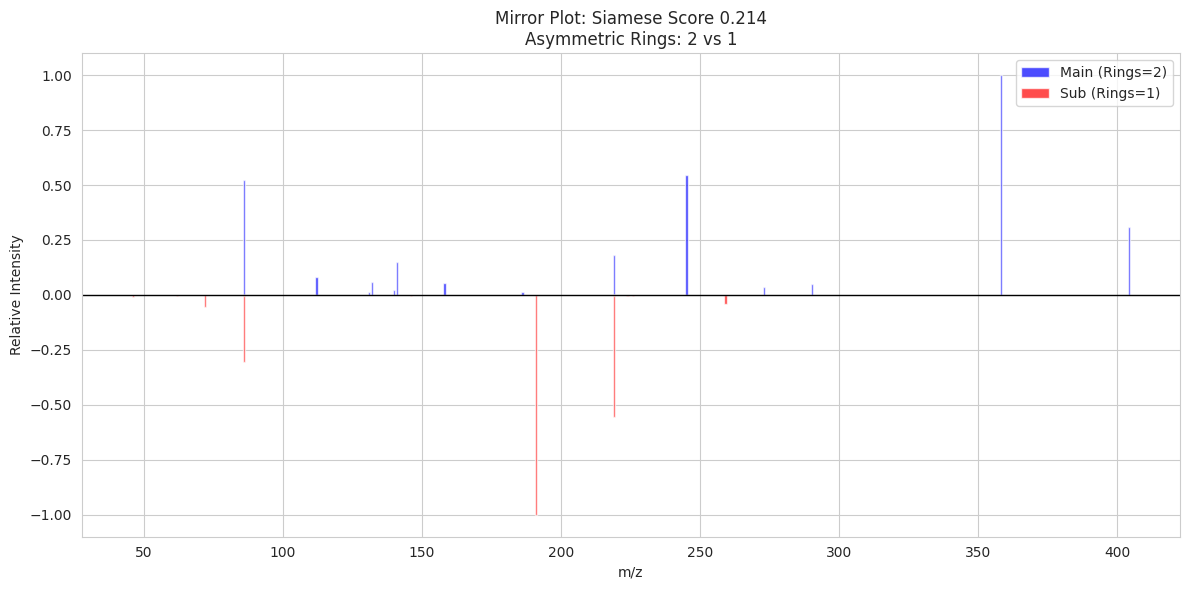

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

# (Using the paths from our previous diagnostics)
PATHS = {
    "sia": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# Load data and lookup
df_sia = pd.read_csv(PATHS["sia"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Find Asymmetric Misses (Ring Diff >= 1, Siamese Score < 0.5)
# We assume the ring metrics are already joined or we'll calculate on the fly
def find_asymmetric_misses(df, n=3):
    misses = df[df['prob_similarity'] < 0.5].copy()
    examples = []
    
    for _, row in misses.iterrows():
        try:
            m1 = Chem.MolFromSmiles(mol_lookup.loc[spec_lookup.loc[row['name_main']]['mol_id']]['smiles'])
            m2 = Chem.MolFromSmiles(mol_lookup.loc[spec_lookup.loc[row['name_sub']]['mol_id']]['smiles'])
            r1, r2 = Descriptors.NumAromaticRings(m1), Descriptors.NumAromaticRings(m2)
            
            if abs(r1 - r2) >= 1: # The Asymmetry criteria
                examples.append({
                    'name_main': row['name_main'], 'name_sub': row['name_sub'],
                    'r_main': r1, 'r_sub': r2, 'score': row['prob_similarity']
                })
            if len(examples) >= n: break
        except: continue
    return examples

examples = find_asymmetric_misses(df_sia)

# --- Plotting Function ---
def plot_mirror(example):
    spec_main = spec_lookup.loc[example['name_main']]
    spec_sub = spec_lookup.loc[example['name_sub']]
    
    plt.figure(figsize=(12, 6))
    
    # Main Spectrum (Top - Positive)
    peaks_main = np.array(spec_main['peaks'])
    plt.bar(peaks_main[:, 0], peaks_main[:, 1], color='blue', alpha=0.7, label=f"Main (Rings={example['r_main']})")
    
    # Sub Spectrum (Bottom - Negative)
    peaks_sub = np.array(spec_sub['peaks'])
    plt.bar(peaks_sub[:, 0], -peaks_sub[:, 1], color='red', alpha=0.7, label=f"Sub (Rings={example['r_sub']})")
    
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Mirror Plot: Siamese Score {example['score']:.3f}\nAsymmetric Rings: {example['r_main']} vs {example['r_sub']}")
    plt.xlabel('m/z')
    plt.ylabel('Relative Intensity')
    plt.legend()
    plt.tight_layout()
    plt.show()

for ex in examples:
    plot_mirror(ex)

In [15]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

# --- 1. SET PATHS ---
PATHS = {
    "iceberg": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "siamese": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD DATA ---
df_ice = pd.read_csv(PATHS["iceberg"])
df_sia = pd.read_csv(PATHS["siamese"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# --- 3. FIND ICEBERG TRUE POSITIVES (5% Risk Zone) ---
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
df_ice_sorted = df_ice.sort_values('conf', ascending=False).copy()
df_ice_sorted['is_fp'] = ((df_ice_sorted['cosine_similarity'] >= 0.5) & (df_ice_sorted['true_label'] == 0)).astype(int)
df_ice_sorted['cum_fp'] = df_ice_sorted['is_fp'].cumsum()
ice_tp_zone = df_ice_sorted[(df_ice_sorted['cum_fp'] <= error_budget) & (df_ice_sorted['true_label'] == 1)].copy()

merged = pd.merge(ice_tp_zone[['name_main', 'name_sub']], 
                  df_sia[['name_main', 'name_sub', 'prob_similarity']], on=['name_main', 'name_sub'])

# --- 4. FIND 5 ASYMMETRIC MISSES ---
missed = merged[merged['prob_similarity'] < 0.5].copy()
selected_pairs = []

for _, row in missed.iterrows():
    try:
        m1_id = spec_lookup.loc[row['name_main']]['mol_id']
        m2_id = spec_lookup.loc[row['name_sub']]['mol_id']
        r1 = Descriptors.NumAromaticRings(Chem.MolFromSmiles(mol_lookup.loc[m1_id]['smiles']))
        r2 = Descriptors.NumAromaticRings(Chem.MolFromSmiles(mol_lookup.loc[m2_id]['smiles']))
        
        if abs(r1 - r2) >= 1: # Found a Heavy vs Light pair!
            selected_pairs.append({
                'name_main': row['name_main'], 'name_sub': row['name_sub'],
                'r1': r1, 'r2': r2, 'score': row['prob_similarity']
            })
            
        if len(selected_pairs) >= 5: # Stop once we have 5
            break
    except: continue

# --- 5. FORMAT AND PRINT OUTPUT ---
if selected_pairs:
    for i, pair in enumerate(selected_pairs, 1):
        s1 = spec_lookup.loc[pair['name_main']]
        s2 = spec_lookup.loc[pair['name_sub']]
        
        # Sort peaks by intensity (descending) and get top 10
        p1 = sorted(s1['peaks'], key=lambda x: x[1], reverse=True)[:10]
        p2 = sorted(s2['peaks'], key=lambda x: x[1], reverse=True)[:10]
        
        print(f"\n{'='*50}")
        print(f"PAIR {i}: ASYMMETRIC MISS")
        print(f"Siamese Score: {pair['score']:.4f}")
        print(f"{'='*50}")
        
        print(f"\n--- MOLECULE 1 (Rings: {pair['r1']}) ---")
        print(f"Precursor m/z: {s1['prec_mz']:.4f}")
        print("Top 10 Peaks (m/z, Intensity):")
        for mz, intensity in p1:
            print(f"  {mz:>8.4f} : {intensity:.4f}")
            
        print(f"\n--- MOLECULE 2 (Rings: {pair['r2']}) ---")
        print(f"Precursor m/z: {s2['prec_mz']:.4f}")
        print("Top 10 Peaks (m/z, Intensity):")
        for mz, intensity in p2:
            print(f"  {mz:>8.4f} : {intensity:.4f}")
else:
    print("Could not find enough asymmetric pairs in the missed zone.")


PAIR 1: ASYMMETRIC MISS
Siamese Score: 0.4776

--- MOLECULE 1 (Rings: 1) ---
Precursor m/z: 240.1706
Top 10 Peaks (m/z, Intensity):
  240.1709 : 1.0000
  128.0452 : 0.0334
  197.1648 : 0.0166
   57.0697 : 0.0140
   71.0852 : 0.0131
   68.0128 : 0.0081
  240.2288 : 0.0072
  240.1132 : 0.0067
   85.0393 : 0.0064
  128.1432 : 0.0061

--- MOLECULE 2 (Rings: 2) ---
Precursor m/z: 363.1737
Top 10 Peaks (m/z, Intensity):
  240.1624 : 1.0000
  363.1736 : 0.1924
  279.1859 : 0.0189
  281.1938 : 0.0060
  240.1054 : 0.0055

PAIR 2: ASYMMETRIC MISS
Siamese Score: 0.4564

--- MOLECULE 1 (Rings: 2) ---
Precursor m/z: 480.2769
Top 10 Peaks (m/z, Intensity):
  128.0706 : 1.0000
  311.0823 : 0.1498
  149.0824 : 0.1087
  480.2791 : 0.0882
   84.0807 : 0.0790
  170.1179 : 0.0442
  128.0791 : 0.0201
  480.1942 : 0.0163
  126.1277 : 0.0114
  128.0930 : 0.0085

--- MOLECULE 2 (Rings: 3) ---
Precursor m/z: 478.1555
Top 10 Peaks (m/z, Intensity):
  128.0706 : 1.0000
   84.0806 : 0.1059
  170.1178 : 0.0392
  

Calculating functional group shifts...

FUNCTIONAL GROUP SHIFT DIAGNOSTICS
            Group  Avg_Shift_Caught  Avg_Shift_Missed       P-Value
4           Ether          0.103858          0.519231  8.638531e-14
5         Halogen          0.050445          0.596154  3.851438e-10
1           Amine          0.017804          0.086538  1.482733e-03
6           Nitro          0.005935          0.048077  2.587679e-03
3          Ketone          0.032641          0.076923  5.203056e-02
2  CarboxylicAcid          0.100890          0.096154  8.909741e-01
0        Hydroxyl          0.243323          0.240385  9.672948e-01


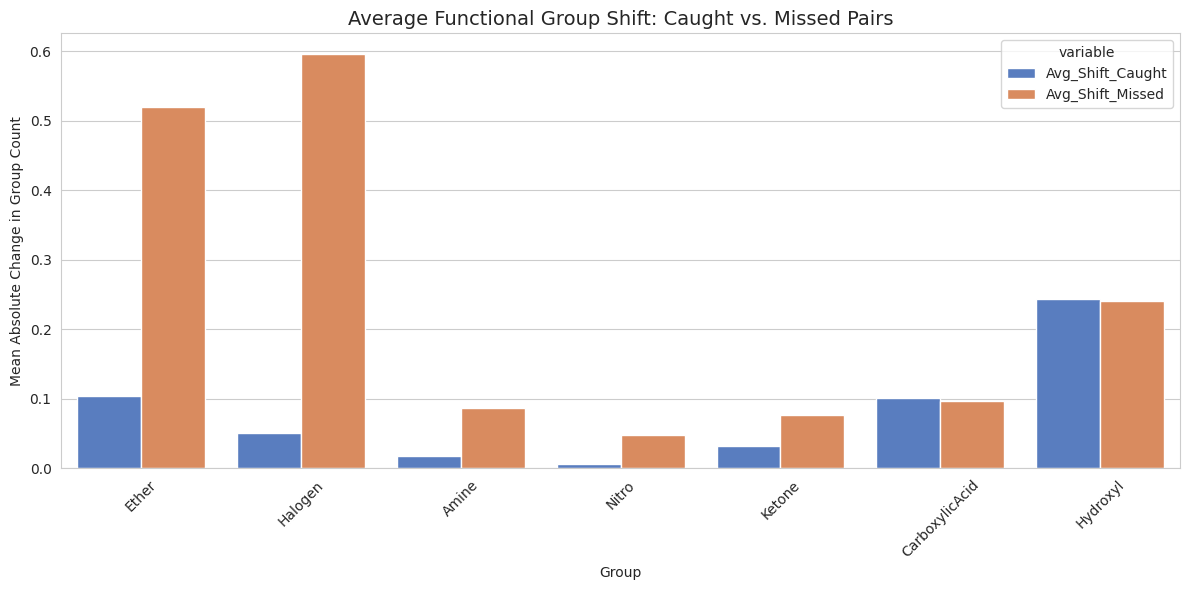

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Fragments
from scipy import stats

# --- 1. CONFIGURATION ---
PATHS = {
    "sia": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "ice": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD & ALIGN (5% RISK ZONE) ---
df_sia = pd.read_csv(PATHS["sia"])
df_ice = pd.read_csv(PATHS["ice"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Re-filter to the 441 pairs (ICEBERG TP / SIAMESE MISS)
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
ice_tp = df_ice.sort_values('conf', ascending=False).copy()
ice_tp['is_fp'] = ((ice_tp['cosine_similarity'] >= 0.5) & (ice_tp['true_label'] == 0)).astype(int)
ice_tp['cum_fp'] = ice_tp['is_fp'].cumsum()
ice_tp_zone = ice_tp[(ice_tp['cum_fp'] <= error_budget) & (ice_tp['true_label'] == 1)]

merged = pd.merge(ice_tp_zone[['name_main', 'name_sub']], 
                  df_sia[['name_main', 'name_sub', 'prob_similarity']], on=['name_main', 'name_sub'])
merged['status'] = np.where(merged['prob_similarity'] >= 0.5, 'Caught', 'Missed')

# --- 3. FUNCTIONAL GROUP EXTRACTION ---
# We define a list of common fragment types to check
fg_functions = {
    'Hydroxyl': Fragments.fr_Al_OH,
    'Amine': Fragments.fr_NH2,
    'CarboxylicAcid': Fragments.fr_COO,
    'Ketone': Fragments.fr_ketone,
    'Ether': Fragments.fr_ether,
    'Halogen': Fragments.fr_halogen,
    'Nitro': Fragments.fr_nitro
}

def get_fg_shifts(row):
    try:
        m1_id = spec_lookup.loc[row['name_main']]['mol_id']
        m2_id = spec_lookup.loc[row['name_sub']]['mol_id']
        mol1 = Chem.MolFromSmiles(mol_lookup.loc[m1_id]['smiles'])
        mol2 = Chem.MolFromSmiles(mol_lookup.loc[m2_id]['smiles'])
        
        shifts = {}
        for name, func in fg_functions.items():
            count1 = func(mol1)
            count2 = func(mol2)
            shifts[f'shift_{name}'] = abs(count1 - count2)
        return pd.Series(shifts)
    except:
        return pd.Series({f'shift_{k}': 0 for k in fg_functions.keys()})

print("Calculating functional group shifts...")
merged_fg = pd.concat([merged, merged.apply(get_fg_shifts, axis=1)], axis=1)

# --- 4. STATISTICAL ANALYSIS ---
print("\n" + "="*50)
print("FUNCTIONAL GROUP SHIFT DIAGNOSTICS")
print("="*50)

summary_list = []
for name in fg_functions.keys():
    col = f'shift_{name}'
    avg_caught = merged_fg[merged_fg['status'] == 'Caught'][col].mean()
    avg_missed = merged_fg[merged_fg['status'] == 'Missed'][col].mean()
    t_stat, p_val = stats.ttest_ind(merged_fg[merged_fg['status'] == 'Caught'][col], 
                                    merged_fg[merged_fg['status'] == 'Missed'][col])
    
    summary_list.append({
        'Group': name,
        'Avg_Shift_Caught': avg_caught,
        'Avg_Shift_Missed': avg_missed,
        'P-Value': p_val
    })

summary_df = pd.DataFrame(summary_list).sort_values('P-Value')
print(summary_df)

# --- 5. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plot_data = summary_df.melt(id_vars='Group', value_vars=['Avg_Shift_Caught', 'Avg_Shift_Missed'])
sns.barplot(data=plot_data, x='Group', y='value', hue='variable', palette='muted')
plt.title('Average Functional Group Shift: Caught vs. Missed Pairs', fontsize=14)
plt.ylabel('Mean Absolute Change in Group Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fg_shift_analysis.png')
plt.show()


FG MISS 1: Halogen Shift=0, Ether Shift=5
Siamese Score: 0.2030


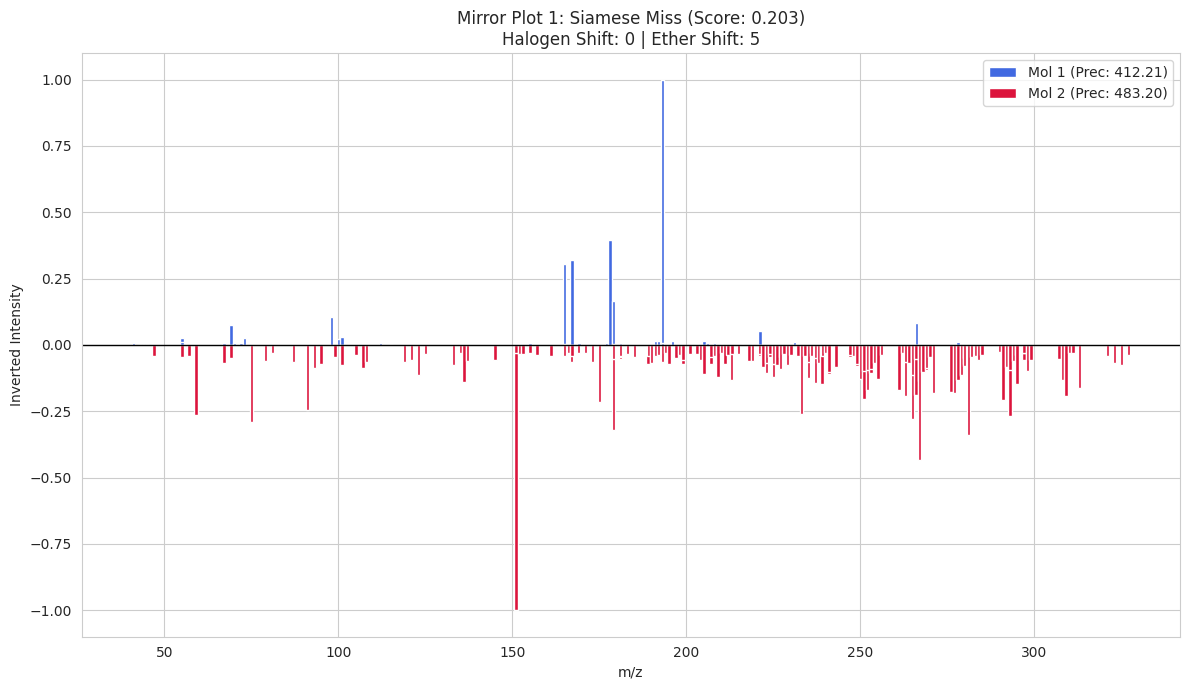


FG MISS 2: Halogen Shift=1, Ether Shift=2
Siamese Score: 0.2884


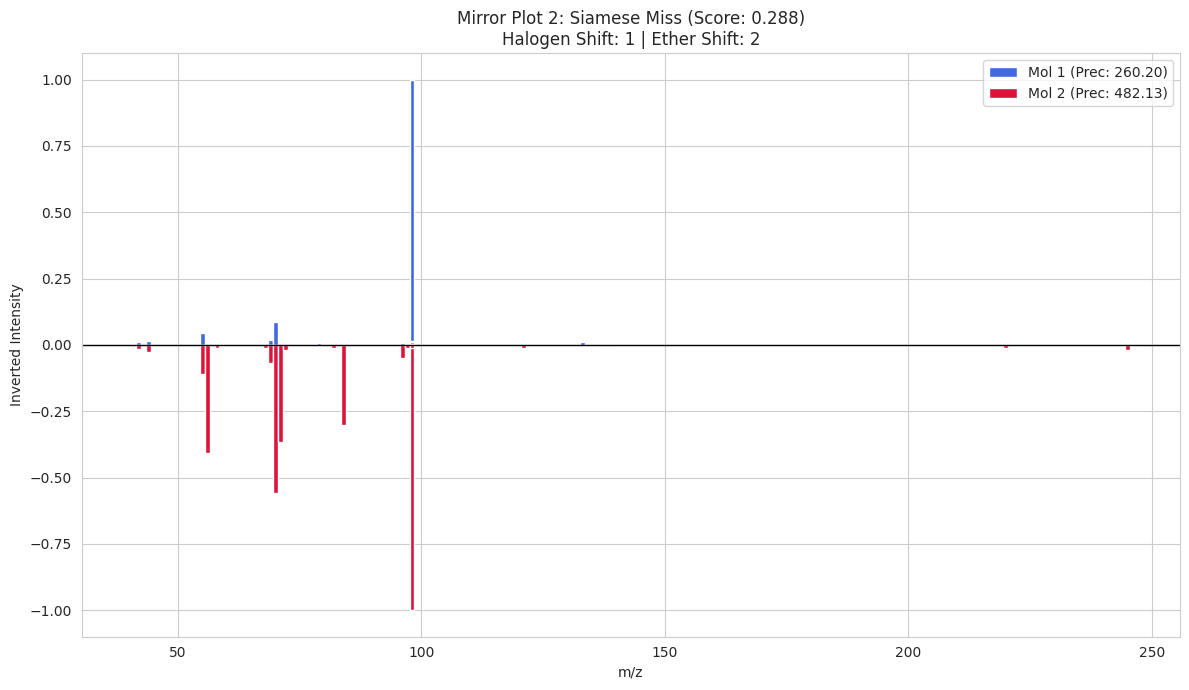


FG MISS 3: Halogen Shift=1, Ether Shift=1
Siamese Score: 0.4373


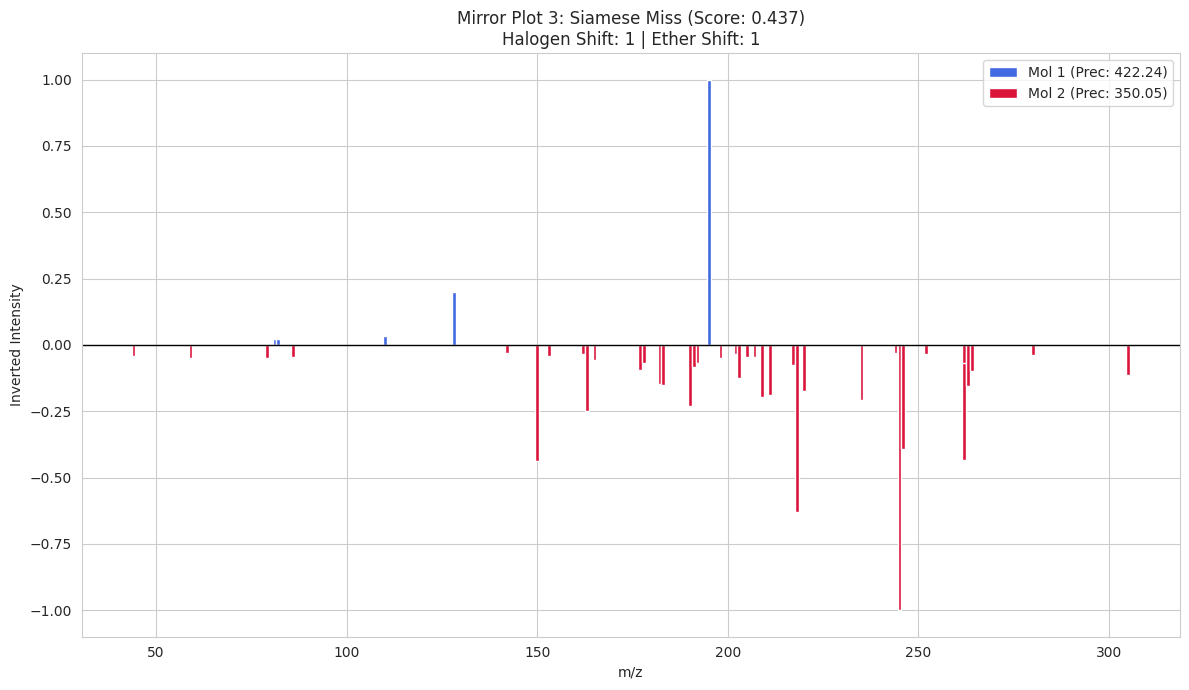


--- Summary ---
Generated text and plots for 3 miss examples.
{'name_main': 'MassSpecGymID0224062', 'name_sub': 'MassSpecGymID0234208', 'h_shift': 0, 'e_shift': 5, 'score': 0.2029959112405777}
{'name_main': 'MassSpecGymID0227730', 'name_sub': 'MassSpecGymID0234032', 'h_shift': 1, 'e_shift': 2, 'score': 0.2883808016777038}
{'name_main': 'MassSpecGymID0214153', 'name_sub': 'MassSpecGymID0236363', 'h_shift': 1, 'e_shift': 1, 'score': 0.4372852742671966}


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Fragments

# --- SET YOUR ENVIRONMENT PATHS ---
PATHS = {
    "sia": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- LOAD DATA ---
df_sia = pd.read_csv(PATHS["sia"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Find 3 targeted Functional Misses
misses = df_sia[df_sia['prob_similarity'] < 0.5].copy()
examples = []

for _, row in misses.iterrows():
    try:
        m1_id = spec_lookup.loc[row['name_main']]['mol_id']
        m2_id = spec_lookup.loc[row['name_sub']]['mol_id']
        m1 = Chem.MolFromSmiles(mol_lookup.loc[m1_id]['smiles'])
        m2 = Chem.MolFromSmiles(mol_lookup.loc[m2_id]['smiles'])
        
        h_shift = abs(Fragments.fr_halogen(m1) - Fragments.fr_halogen(m2))
        e_shift = abs(Fragments.fr_ether(m1) - Fragments.fr_ether(m2))
        
        if h_shift >= 1 or e_shift >= 1:
            examples.append({
                'name_main': row['name_main'], 'name_sub': row['name_sub'],
                'h_shift': h_shift, 'e_shift': e_shift, 'score': row['prob_similarity']
            })
        if len(examples) >= 3: break
    except: continue

# --- PLOTTING & TEXT OUTPUT ---
for i, ex in enumerate(examples, 1):
    s1, s2 = spec_lookup.loc[ex['name_main']], spec_lookup.loc[ex['name_sub']]
    
    # 1. Text Summary
    p1 = sorted(s1['peaks'], key=lambda x: x[1], reverse=True)[:8]
    p2 = sorted(s2['peaks'], key=lambda x: x[1], reverse=True)[:8]
    
    print(f"\n{'='*60}")
    print(f"FG MISS {i}: Halogen Shift={ex['h_shift']}, Ether Shift={ex['e_shift']}")
    print(f"Siamese Score: {ex['score']:.4f}")
    print(f"{'='*60}")
    
    # 2. Mirror Plot Visualization
    plt.figure(figsize=(12, 7))
    
    # Molecule 1 (Top)
    peaks1 = np.array(s1['peaks'])
    plt.bar(peaks1[:, 0], peaks1[:, 1], width=1.0, color='royalblue', label=f"Mol 1 (Prec: {s1['prec_mz']:.2f})")
    
    # Molecule 2 (Bottom - Inverted)
    peaks2 = np.array(s2['peaks'])
    plt.bar(peaks2[:, 0], -peaks2[:, 1], width=1.0, color='crimson', label=f"Mol 2 (Prec: {s2['prec_mz']:.2f})")
    
    plt.axhline(0, color='black', lw=1)
    plt.title(f"Mirror Plot {i}: Siamese Miss (Score: {ex['score']:.3f})\nHalogen Shift: {ex['h_shift']} | Ether Shift: {ex['e_shift']}")
    plt.xlabel("m/z")
    plt.ylabel("Inverted Intensity")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"fg_mirror_plot_{i}.png")
    plt.show()

print("\n--- Summary ---")
print(f"Generated text and plots for {len(examples)} miss examples.")
for pair in examples:
    print(pair)

In [18]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Fragments, Descriptors

# --- 1. SET PATHS ---
PATHS = {
    "sia": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD DATA ---
df_sia = pd.read_csv(PATHS["sia"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# --- 3. FIND 3 TARGETED FUNCTIONAL MISSES ---
misses = df_sia[df_sia['prob_similarity'] < 0.5].copy()
examples = []

for _, row in misses.iterrows():
    try:
        m1 = Chem.MolFromSmiles(mol_lookup.loc[spec_lookup.loc[row['name_main']]['mol_id']]['smiles'])
        m2 = Chem.MolFromSmiles(mol_lookup.loc[spec_lookup.loc[row['name_sub']]['mol_id']]['smiles'])
        
        # Check for Halogen or Ether shift
        h_shift = abs(Fragments.fr_halogen(m1) - Fragments.fr_halogen(m2))
        e_shift = abs(Fragments.fr_ether(m1) - Fragments.fr_ether(m2))
        
        if h_shift >= 1 or e_shift >= 1:
            examples.append({
                'name_main': row['name_main'], 'name_sub': row['name_sub'],
                'h_shift': h_shift, 'e_shift': e_shift, 'score': row['prob_similarity']
            })
        if len(examples) >= 3: break
    except: continue

# --- 4. OUTPUT PEAK DATA ---
for i, ex in enumerate(examples, 1):
    s1, s2 = spec_lookup.loc[ex['name_main']], spec_lookup.loc[ex['name_sub']]
    p1 = sorted(s1['peaks'], key=lambda x: x[1], reverse=True)[:8]
    p2 = sorted(s2['peaks'], key=lambda x: x[1], reverse=True)[:8]
    
    print(f"\n{'='*60}")
    print(f"FG MISS {i}: Halogen Shift={ex['h_shift']}, Ether Shift={ex['e_shift']}")
    print(f"Siamese Score: {ex['score']:.4f}")
    print(f"{'='*60}")
    
    print(f"MOLECULE 1 (Prec: {s1['prec_mz']:.2f}) Top Peaks:")
    for mz, inten in p1: print(f"  {mz:>8.2f} ({inten:.3f})")
    
    print(f"\nMOLECULE 2 (Prec: {s2['prec_mz']:.2f}) Top Peaks:")
    for mz, inten in p2: print(f"  {mz:>8.2f} ({inten:.3f})")


FG MISS 1: Halogen Shift=0, Ether Shift=5
Siamese Score: 0.2030
MOLECULE 1 (Prec: 412.21) Top Peaks:
    193.10 (1.000)
    178.08 (0.395)
    167.09 (0.320)
    165.07 (0.305)
    179.09 (0.165)
     98.06 (0.104)
    266.15 (0.083)
     69.07 (0.075)

MOLECULE 2 (Prec: 483.20) Top Peaks:
    151.08 (1.000)
    267.10 (0.433)
    281.12 (0.339)
    179.07 (0.319)
     75.04 (0.289)
    265.09 (0.281)
    293.08 (0.268)
     59.05 (0.264)

FG MISS 2: Halogen Shift=1, Ether Shift=2
Siamese Score: 0.2884
MOLECULE 1 (Prec: 260.20) Top Peaks:
     98.10 (1.000)
     70.06 (0.087)
     55.05 (0.046)
     69.07 (0.017)
     44.05 (0.014)
     98.10 (0.014)
     98.11 (0.013)
    133.06 (0.009)

MOLECULE 2 (Prec: 482.13) Top Peaks:
     98.10 (1.000)
     70.06 (0.559)
     56.05 (0.406)
     71.07 (0.365)
     84.08 (0.303)
     55.05 (0.111)
     69.07 (0.066)
     96.08 (0.051)

FG MISS 3: Halogen Shift=1, Ether Shift=1
Siamese Score: 0.4373
MOLECULE 1 (Prec: 422.24) Top Peaks:
    195.09

Calculating Connectivity and Composition metrics...

CONNECTIVITY VS COMPOSITION DIAGNOSTICS
                     pair_type  total_pairs  misses  avg_tanimoto  avg_mass_diff  failure_rate
Analogs (Diff Comp, High Conn)          177       7         0.751         25.248         3.955
 Distant (Diff Comp, Low Conn)          166      84         0.289         81.651        50.602
Isomers (Same Comp, Diff Conn)           98      13         0.537          0.000        13.265

Scatter plot saved as conn_vs_comp_scatter.png


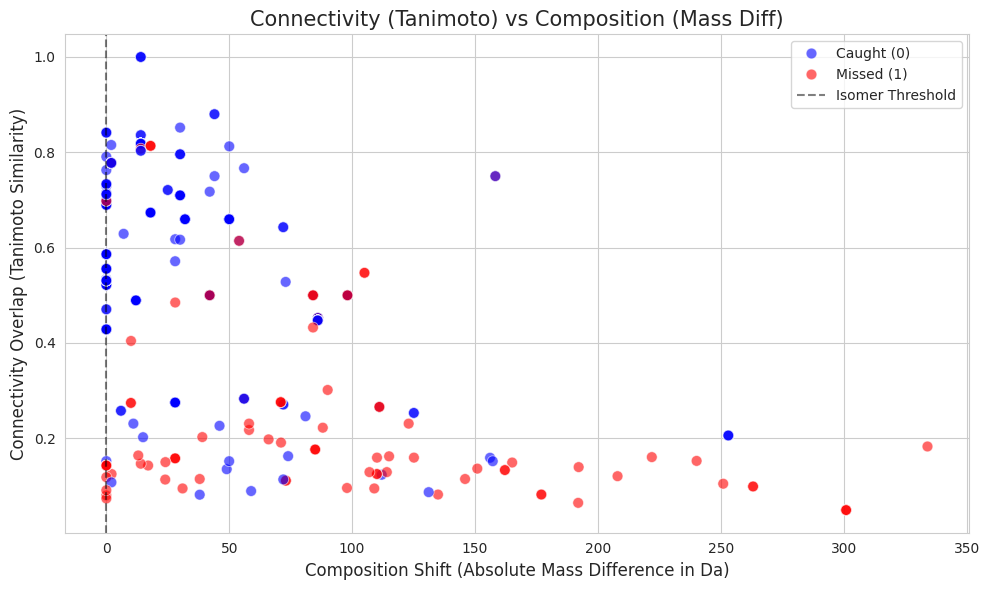

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit import DataStructs
from scipy import stats

# --- 1. SET PATHS ---
PATHS = {
    "sia": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "ice": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD & ALIGN (5% RISK ZONE) ---
df_sia = pd.read_csv(PATHS["sia"])
df_ice = pd.read_csv(PATHS["ice"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
ice_tp = df_ice.sort_values('conf', ascending=False).copy()
ice_tp['is_fp'] = ((ice_tp['cosine_similarity'] >= 0.5) & (ice_tp['true_label'] == 0)).astype(int)
ice_tp['cum_fp'] = ice_tp['is_fp'].cumsum()
ice_tp_zone = ice_tp[(ice_tp['cum_fp'] <= error_budget) & (ice_tp['true_label'] == 1)]

merged = pd.merge(ice_tp_zone[['name_main', 'name_sub']], 
                  df_sia[['name_main', 'name_sub', 'prob_similarity']], on=['name_main', 'name_sub'])
merged['is_miss'] = (merged['prob_similarity'] < 0.5).astype(int)

# --- 3. CALCULATE COMPOSITION AND CONNECTIVITY ---
def get_conn_comp(row):
    try:
        m1_id = spec_lookup.loc[row['name_main']]['mol_id']
        m2_id = spec_lookup.loc[row['name_sub']]['mol_id']
        m1 = Chem.MolFromSmiles(mol_lookup.loc[m1_id]['smiles'])
        m2 = Chem.MolFromSmiles(mol_lookup.loc[m2_id]['smiles'])
        
        # Composition: Absolute Exact Mass Difference
        mass_diff = abs(Descriptors.ExactMolWt(m1) - Descriptors.ExactMolWt(m2))
        
        # Connectivity: Morgan Fingerprint (Radius 2) Tanimoto Similarity
        fp1 = AllChem.GetMorganFingerprintAsBitVect(m1, 2, nBits=2048)
        fp2 = AllChem.GetMorganFingerprintAsBitVect(m2, 2, nBits=2048)
        tanimoto = DataStructs.TanimotoSimilarity(fp1, fp2)
        
        return pd.Series({'mass_diff': mass_diff, 'tanimoto': tanimoto})
    except:
        return pd.Series({'mass_diff': np.nan, 'tanimoto': np.nan})

print("Calculating Connectivity and Composition metrics...")
merged[['mass_diff', 'tanimoto']] = merged.apply(get_conn_comp, axis=1)
merged = merged.dropna(subset=['mass_diff', 'tanimoto'])

# --- 4. CATEGORIZE INTO CHEMICAL ZONES ---
def categorize_pair(row):
    # Isomers: Same composition (mass diff < 0.01 Da)
    if row['mass_diff'] < 0.01:
        return 'Isomers (Same Comp, Diff Conn)'
    # High Structural Similarity Analogs
    elif row['tanimoto'] >= 0.6:
        return 'Analogs (Diff Comp, High Conn)'
    # Distant Pairs
    else:
        return 'Distant (Diff Comp, Low Conn)'

merged['pair_type'] = merged.apply(categorize_pair, axis=1)

# --- 5. AGGREGATE RESULTS ---
summary = merged.groupby('pair_type').agg(
    total_pairs=('is_miss', 'count'),
    misses=('is_miss', 'sum'),
    avg_tanimoto=('tanimoto', 'mean'),
    avg_mass_diff=('mass_diff', 'mean')
).reset_index()

summary['failure_rate'] = (summary['misses'] / summary['total_pairs']) * 100

print("\n" + "="*70)
print("CONNECTIVITY VS COMPOSITION DIAGNOSTICS")
print("="*70)
print(summary.to_string(index=False, float_format="%.3f"))

# --- 6. VISUALIZATION: SCATTER PLOT ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=merged, x='mass_diff', y='tanimoto', hue='is_miss', 
    palette={0: 'blue', 1: 'red'}, alpha=0.6, s=60
)
plt.axvline(x=0.01, color='black', linestyle='--', alpha=0.5, label='Isomer Threshold')
plt.title('Connectivity (Tanimoto) vs Composition (Mass Diff)', fontsize=15)
plt.xlabel('Composition Shift (Absolute Mass Difference in Da)', fontsize=12)
plt.ylabel('Connectivity Overlap (Tanimoto Similarity)', fontsize=12)

# Custom legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=[handles[0], handles[1], handles[2]], 
           labels=['Caught (0)', 'Missed (1)', 'Isomer Threshold'])
plt.tight_layout()
plt.savefig('conn_vs_comp_scatter.png')
print("\nScatter plot saved as conn_vs_comp_scatter.png")

## Debugging the worse offender

Analyzing 104 missed pairs against the 4 failure factors...

PROPORTION OF MISSES BY FAILURE FACTOR
         Failure Factor  Count  Percentage (%)
F4 Global Topology Drop     80            76.9
  F3 FG Shift Hal/Ether     52            50.0
  F2 Aromatic Asymmetry     46            44.2
         F1 Low Anchors     11            10.6

*Note: Percentages sum to >100% because a single miss can trigger multiple factors.

Saved bar chart as failure_attribution_summary.png


/tmp/ipykernel_2619556/2333483434.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x='Percentage (%)', y='Failure Factor', palette='magma')


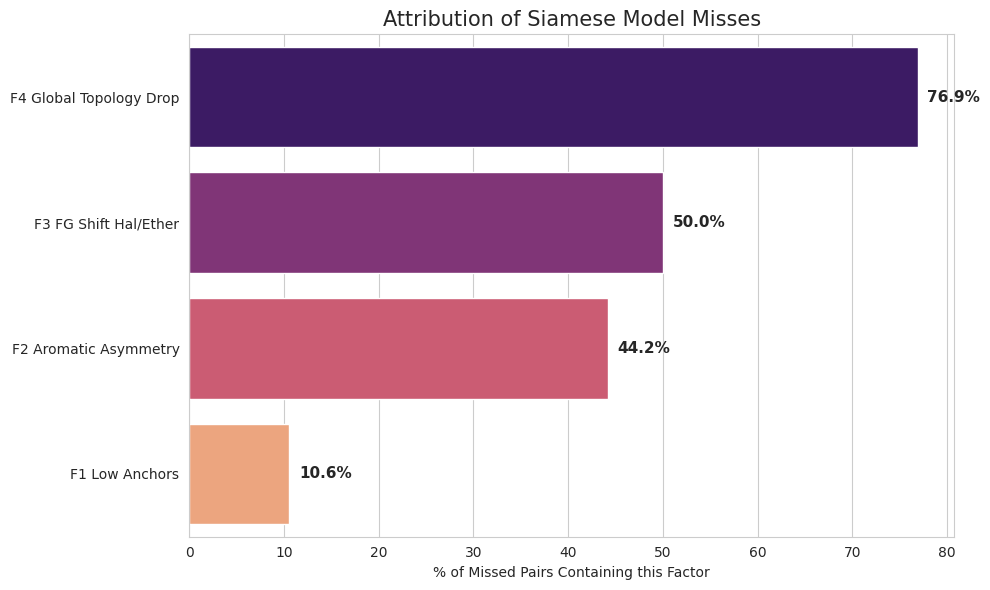

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Fragments
from rdkit import DataStructs

# --- 1. SET PATHS ---
PATHS = {
    "sia": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv",
    "ice": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/msg_iceberg_predictions/iceberg_classification_results.csv",
    "mol": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl",
    "spec": "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
}

# --- 2. LOAD DATA & ISOLATE MISSES ---
df_sia = pd.read_csv(PATHS["sia"])
df_ice = pd.read_csv(PATHS["ice"])
mol_lookup = pd.read_pickle(PATHS["mol"]).set_index('mol_id')
spec_lookup = pd.read_pickle(PATHS["spec"]).set_index('spec_id')

# Re-isolate the 441 ICEBERG TP / Siamese Misses
total_neg = (df_sia['true_label'] == 0).sum()
error_budget = int(total_neg * 0.05)
df_ice['conf'] = np.abs(df_ice['cosine_similarity'] - 0.5)
ice_tp = df_ice.sort_values('conf', ascending=False).copy()
ice_tp['is_fp'] = ((ice_tp['cosine_similarity'] >= 0.5) & (ice_tp['true_label'] == 0)).astype(int)
ice_tp['cum_fp'] = ice_tp['is_fp'].cumsum()
ice_tp_zone = ice_tp[(ice_tp['cum_fp'] <= error_budget) & (ice_tp['true_label'] == 1)]

merged = pd.merge(ice_tp_zone[['name_main', 'name_sub']], 
                  df_sia[['name_main', 'name_sub', 'prob_similarity']], on=['name_main', 'name_sub'])
misses = merged[merged['prob_similarity'] < 0.5].copy()

# --- 3. DEFINE FAILURE TAGGING FUNCTIONS (UPDATED) ---
def check_shared_anchors(row):
    s1_peaks = spec_lookup.loc[row['name_main']]['peaks']
    s2_peaks = spec_lookup.loc[row['name_sub']]['peaks']
    
    # Safety check: if loc returns a DataFrame (due to duplicates), grab the first item
    if isinstance(s1_peaks, pd.Series): s1_peaks = s1_peaks.iloc[0]
    if isinstance(s2_peaks, pd.Series): s2_peaks = s2_peaks.iloc[0]
    
    top5_m1 = [p[0] for p in sorted(s1_peaks, key=lambda x: x[1], reverse=True)[:5]]
    top5_m2 = [p[0] for p in sorted(s2_peaks, key=lambda x: x[1], reverse=True)[:5]]
    
    shared = 0
    for mz1 in top5_m1:
        if any(abs(mz1 - mz2) < 0.1 for mz2 in top5_m2):
            shared += 1
    return 1 if shared < 2 else 0

def tag_failure_modes(row):
    # NO try...except block here. We want to see the error!
    m1_id = spec_lookup.loc[row['name_main']]['mol_id']
    m2_id = spec_lookup.loc[row['name_sub']]['mol_id']
    
    # Safety check for duplicates
    if isinstance(m1_id, pd.Series): m1_id = m1_id.iloc[0]
    if isinstance(m2_id, pd.Series): m2_id = m2_id.iloc[0]
    
    mol1 = Chem.MolFromSmiles(mol_lookup.loc[m1_id]['smiles'])
    mol2 = Chem.MolFromSmiles(mol_lookup.loc[m2_id]['smiles'])
    
    # 1. Spectral: Low Shared Anchors
    low_anchors = check_shared_anchors(row)
    
    # 2. Structural: Aromatic Asymmetry & Complexity
    r1, r2 = Descriptors.NumAromaticRings(mol1), Descriptors.NumAromaticRings(mol2)
    aromatic_asym = 1 if (abs(r1 - r2) >= 1 and max(r1, r2) >= 2) else 0
    
    # 3. Structural: Problematic Functional Groups (Ether/Halogen)
    h_shift = abs(Fragments.fr_halogen(mol1) - Fragments.fr_halogen(mol2))
    e_shift = abs(Fragments.fr_ether(mol1) - Fragments.fr_ether(mol2))
    fg_shift = 1 if (h_shift >= 1 or e_shift >= 1) else 0
    
    # 4. Global Topology: Tanimoto < 0.5 (Structural proxy failure)
    fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, 2, nBits=2048)
    fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, 2, nBits=2048)
    tanimoto = DataStructs.TanimotoSimilarity(fp1, fp2)
    global_proxy_fail = 1 if tanimoto < 0.5 else 0
    
    return pd.Series({
        'F1_Low_Anchors': low_anchors,
        'F2_Aromatic_Asymmetry': aromatic_asym,
        'F3_FG_Shift_Hal/Ether': fg_shift,
        'F4_Global_Topology_Drop': global_proxy_fail
    })

print(f"Analyzing {len(misses)} missed pairs against the 4 failure factors...")
tags = misses.apply(tag_failure_modes, axis=1)

# --- 4. CALCULATE PROPORTIONS ---
results = []
total_misses = len(misses)

for col in tags.columns:
    count = tags[col].sum()
    pct = (count / total_misses) * 100
    results.append({'Failure Factor': col.replace('_', ' '), 'Count': count, 'Percentage (%)': pct})

results_df = pd.DataFrame(results).sort_values(by='Percentage (%)', ascending=False)

print("\n" + "="*60)
print("PROPORTION OF MISSES BY FAILURE FACTOR")
print("="*60)
print(results_df.to_string(index=False, float_format="%.1f"))
print("\n*Note: Percentages sum to >100% because a single miss can trigger multiple factors.")

# --- 5. VISUALIZE MULTI-FACTOR IMPACT ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=results_df, x='Percentage (%)', y='Failure Factor', palette='magma')
plt.title('Attribution of Siamese Model Misses', fontsize=15)
plt.xlabel('% of Missed Pairs Containing this Factor')
plt.ylabel('')
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%", (p.get_width() + 1, p.get_y() + p.get_height() / 2.),
                va='center', ha='left', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('failure_attribution_summary.png')
print("\nSaved bar chart as failure_attribution_summary.png")

## Analyzing the Sinkhorn Transport Model

In [1]:
import pandas as pd
from IPython.display import display, HTML

# Path to the Stage 2 relaxed guardrails predictions
csv_path = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv"

# Load the data
print(f"[*] Loading predictions from: {csv_path}\n")
df = pd.read_csv(csv_path)

# Calculate the "Error Margin" (Absolute difference between True Label and Predicted Probability)
df['error_margin'] = abs(df['true_label'] - df['prob_similarity'])

# =========================================================
# 1. Confident False Positives (Hallucinations)
# True Label = 0 (Not Similar), but Model Predicted > 0.5
# Sorted by highest probability first (Most confident errors)
# =========================================================
fps = df[(df['true_label'] == 0.0) & (df['predicted_label'] == 1.0)].copy()
top_fps = fps.sort_values(by='prob_similarity', ascending=False).head(10)

display(HTML("<h3>🚨 TOP 10 CONFIDENT FALSE POSITIVES (Hallucinations) 🚨</h3>"))
display(HTML("<p><em>The model was absolutely certain these spectra matched, but they didn't.</em></p>"))
display(top_fps[['name_main', 'name_sub', 'mass_diff', 'mass_regime', 'prob_similarity']])


# =========================================================
# 2. Confident False Negatives (Blind Spots)
# True Label = 1 (Similar), but Model Predicted < 0.5
# Sorted by lowest probability first (Most confident errors)
# =========================================================
fns = df[(df['true_label'] == 1.0) & (df['predicted_label'] == 0.0)].copy()
top_fns = fns.sort_values(by='prob_similarity', ascending=True).head(10)

display(HTML("<hr>"))
display(HTML("<h3>🚨 TOP 10 CONFIDENT FALSE NEGATIVES (Blind Spots) 🚨</h3>"))
display(HTML("<p><em>The model was absolutely certain these spectra were different, but they actually matched.</em></p>"))
display(top_fns[['name_main', 'name_sub', 'mass_diff', 'mass_regime', 'prob_similarity']])

[*] Loading predictions from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv



,name_main,name_sub,mass_diff,mass_regime,prob_similarity
1383,MassSpecGymID0078208,MassSpecGymID0078912,12.000000,3. Medium (10-50 Da),0.933087
1519,MassSpecGymID0234862,MassSpecGymID0235348,15.970459,3. Medium (10-50 Da),0.930212
1430,MassSpecGymID0232324,MassSpecGymID0238539,13.031647,3. Medium (10-50 Da),0.925239
1451,MassSpecGymID0000897,MassSpecGymID0001312,15.994904,3. Medium (10-50 Da),0.924476
417,MassSpecGymID0217002,MassSpecGymID0217116,44.026215,3. Medium (10-50 Da),0.915411
688,MassSpecGymID0216034,MassSpecGymID0231527,30.010560,3. Medium (10-50 Da),0.912558
1028,MassSpecGymID0078208,MassSpecGymID0079014,2.015595,2. Tiny (1-10 Da),0.910430
1504,MassSpecGymID0020231,MassSpecGymID0059256,118.078200,5. Huge (>100 Da),0.908714
144,MassSpecGymID0215967,MassSpecGymID0217676,14.015625,3. Medium (10-50 Da),0.906941
1470,MassSpecGymID0109540,MassSpecGymID0110023,30.010560,3. Medium (10-50 Da),0.900314


,name_main,name_sub,mass_diff,mass_regime,prob_similarity
0,MassSpecGymID0003031,MassSpecGymID0049401,84.093900,4. Large (50-100 Da),0.042350
647,MassSpecGymID0075020,MassSpecGymID0078830,27.994904,3. Medium (10-50 Da),0.060768
119,MassSpecGymID0078831,MassSpecGymID0078908,58.005510,4. Large (50-100 Da),0.062123
1613,MassSpecGymID0078830,MassSpecGymID0078916,58.005510,4. Large (50-100 Da),0.062221
1110,MassSpecGymID0078833,MassSpecGymID0078915,58.005510,4. Large (50-100 Da),0.064585
1019,MassSpecGymID0075028,MassSpecGymID0078908,86.000410,4. Large (50-100 Da),0.065719
660,MassSpecGymID0075035,MassSpecGymID0078833,27.994904,3. Medium (10-50 Da),0.067909
836,MassSpecGymID0075026,MassSpecGymID0078760,42.010605,3. Medium (10-50 Da),0.072181
1114,MassSpecGymID0075028,MassSpecGymID0078914,86.000410,4. Large (50-100 Da),0.074246
976,MassSpecGymID0060728,MassSpecGymID0064545,24.037994,3. Medium (10-50 Da),0.077598


[*] Using device: cuda
[*] Initializing Stage 1 Model architecture...


/data/nas-gpu/wang/tmach007/massformer/y/envs/MF-GPU/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/tmp/ipykernel_3983783/3684294947.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly

[*] Loading Trained Stage 1 Weights from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/flare/new/massformer_flare_stage1_new_best.pt
[*] Loading Datasets & Predictions...
[*] Loading Spectral Data from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl
[*] Loading Molecular Data from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl
[+] Dataset initialized with 227308 valid molecule-spectrum pairs.


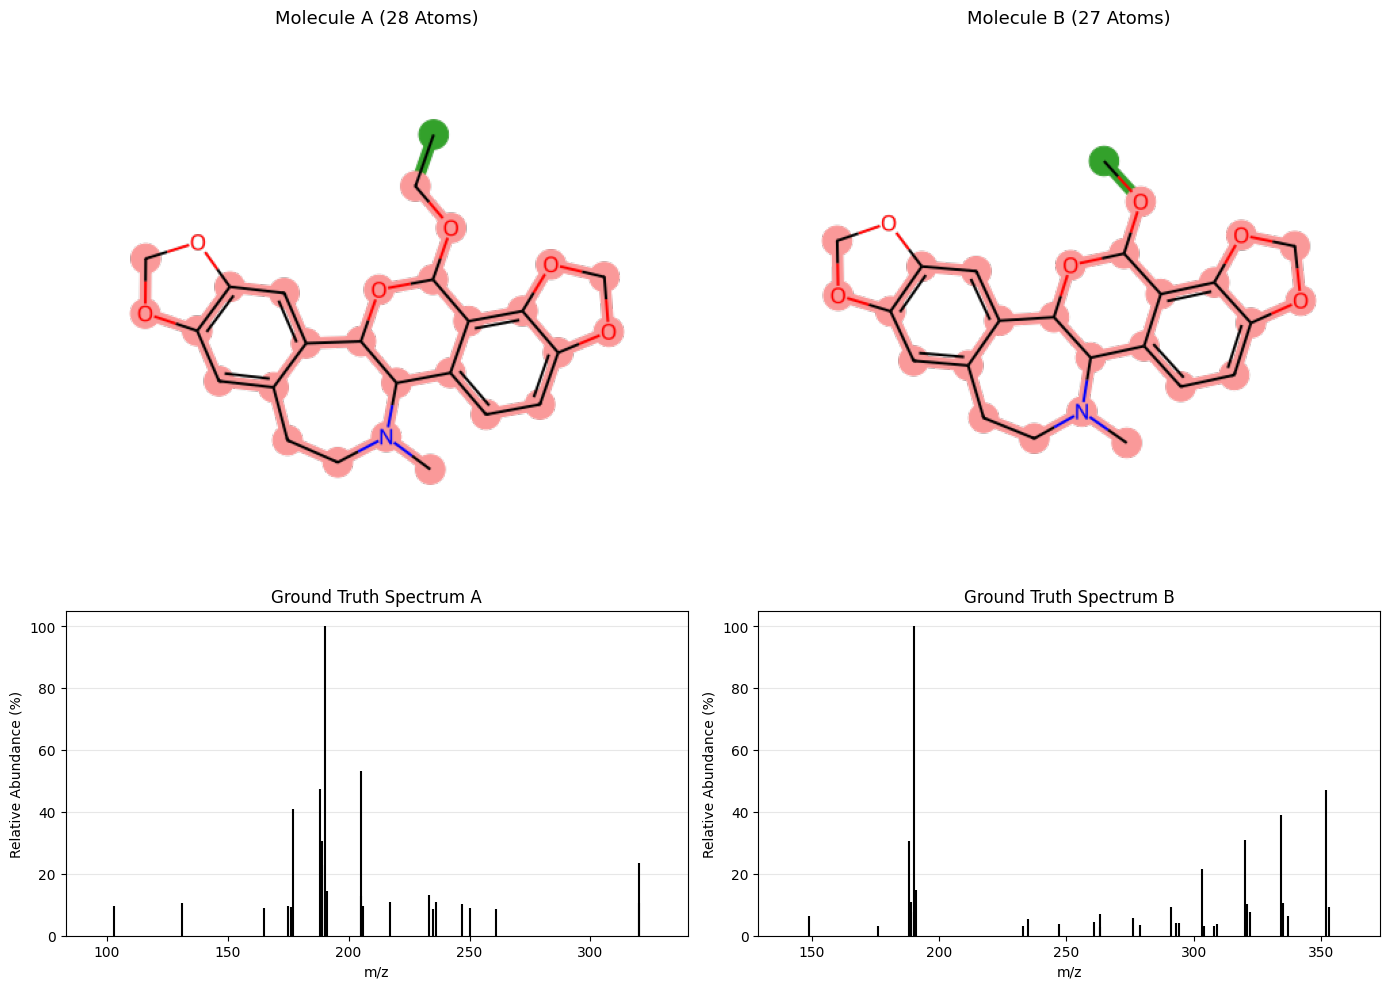

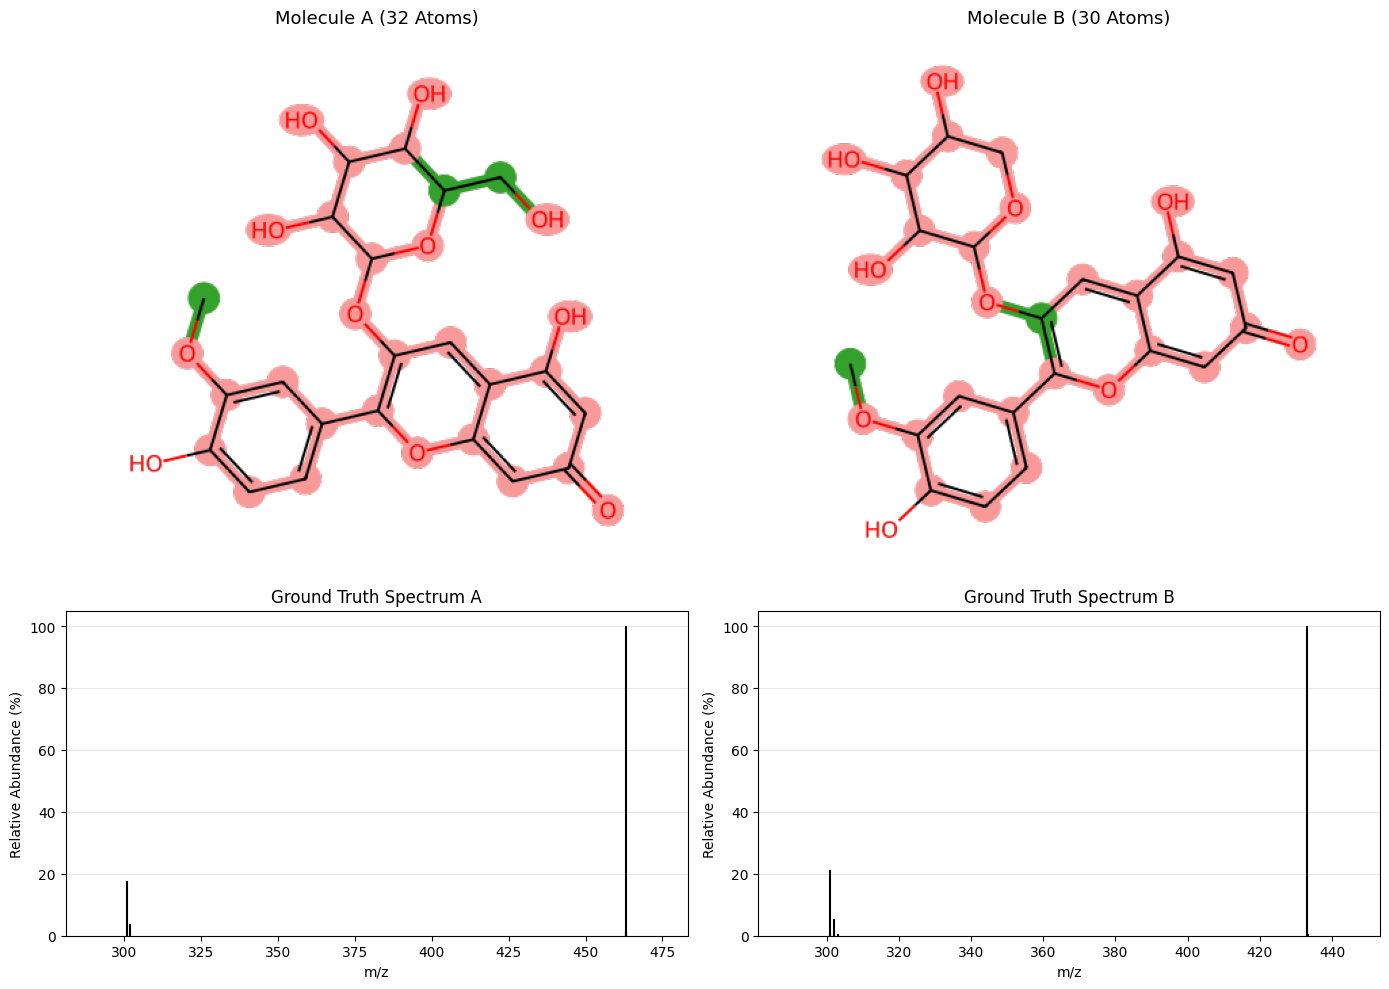

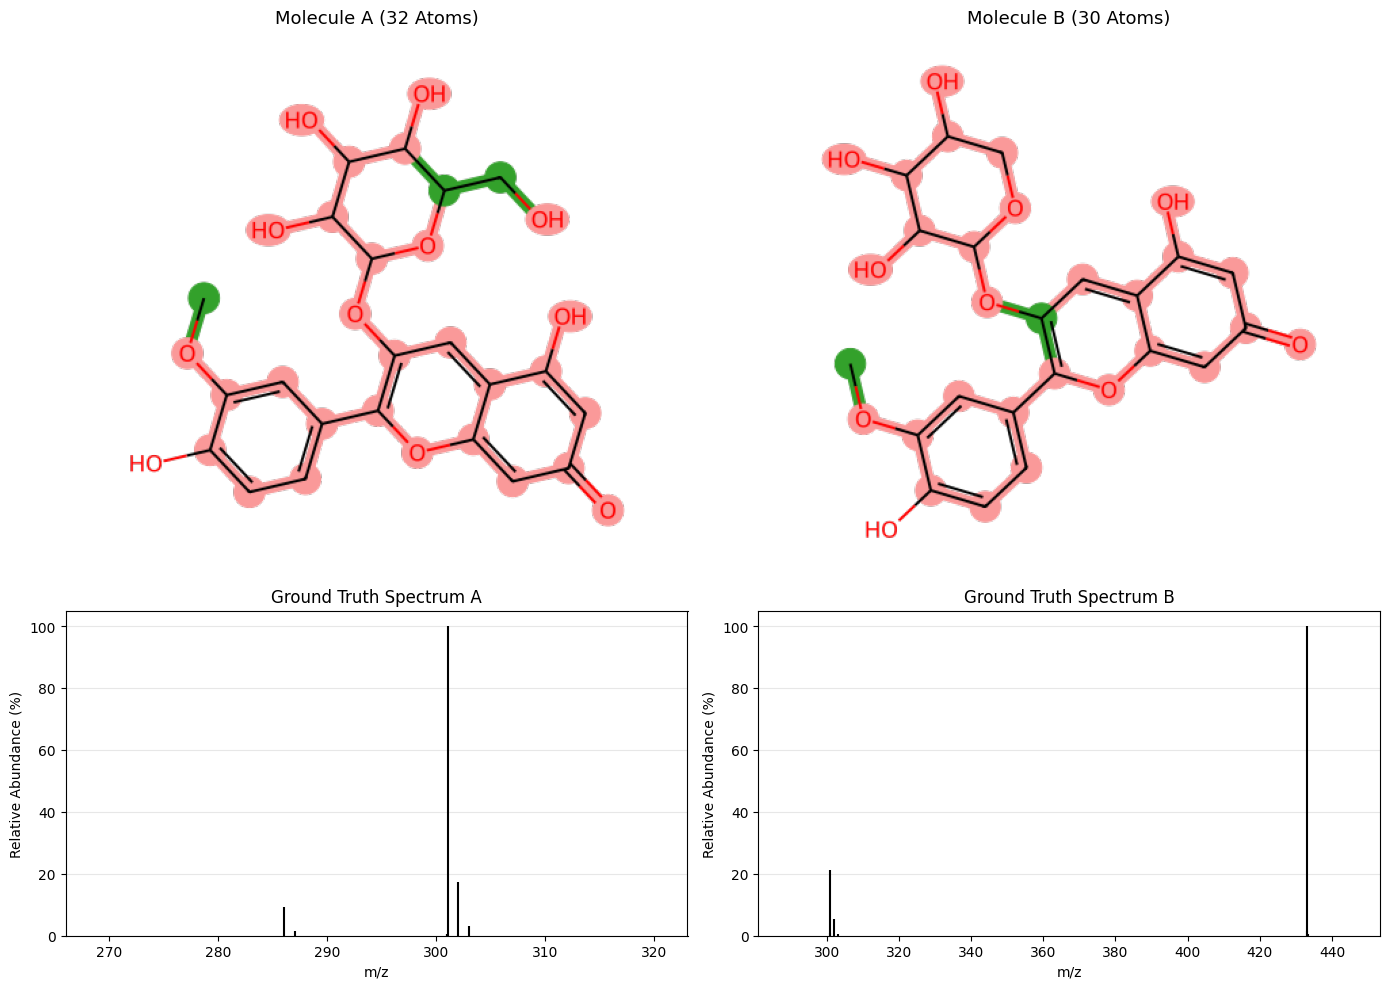

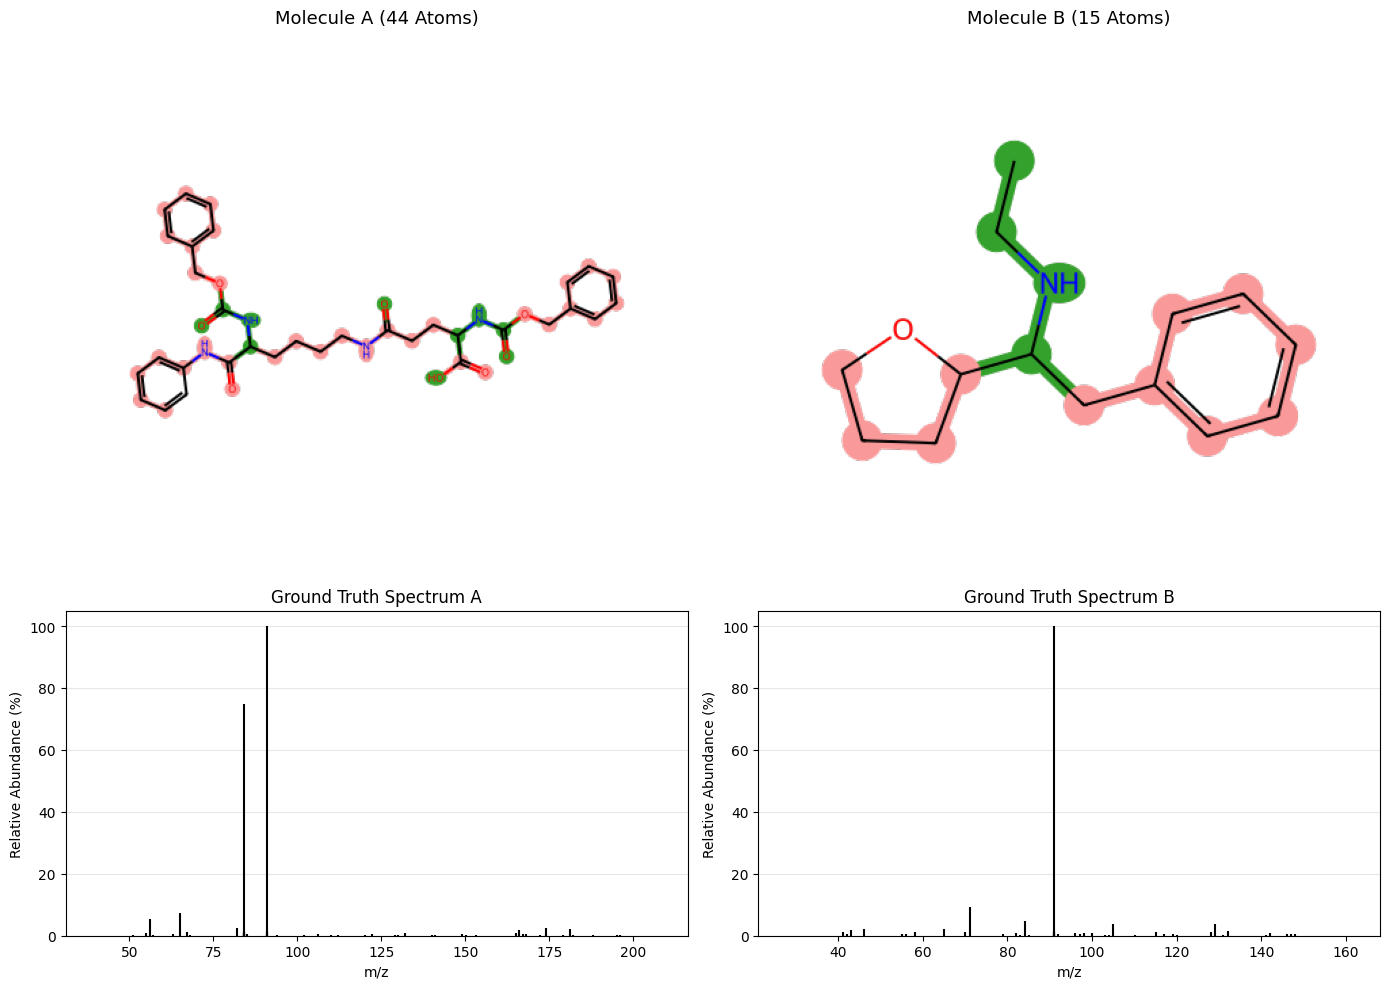

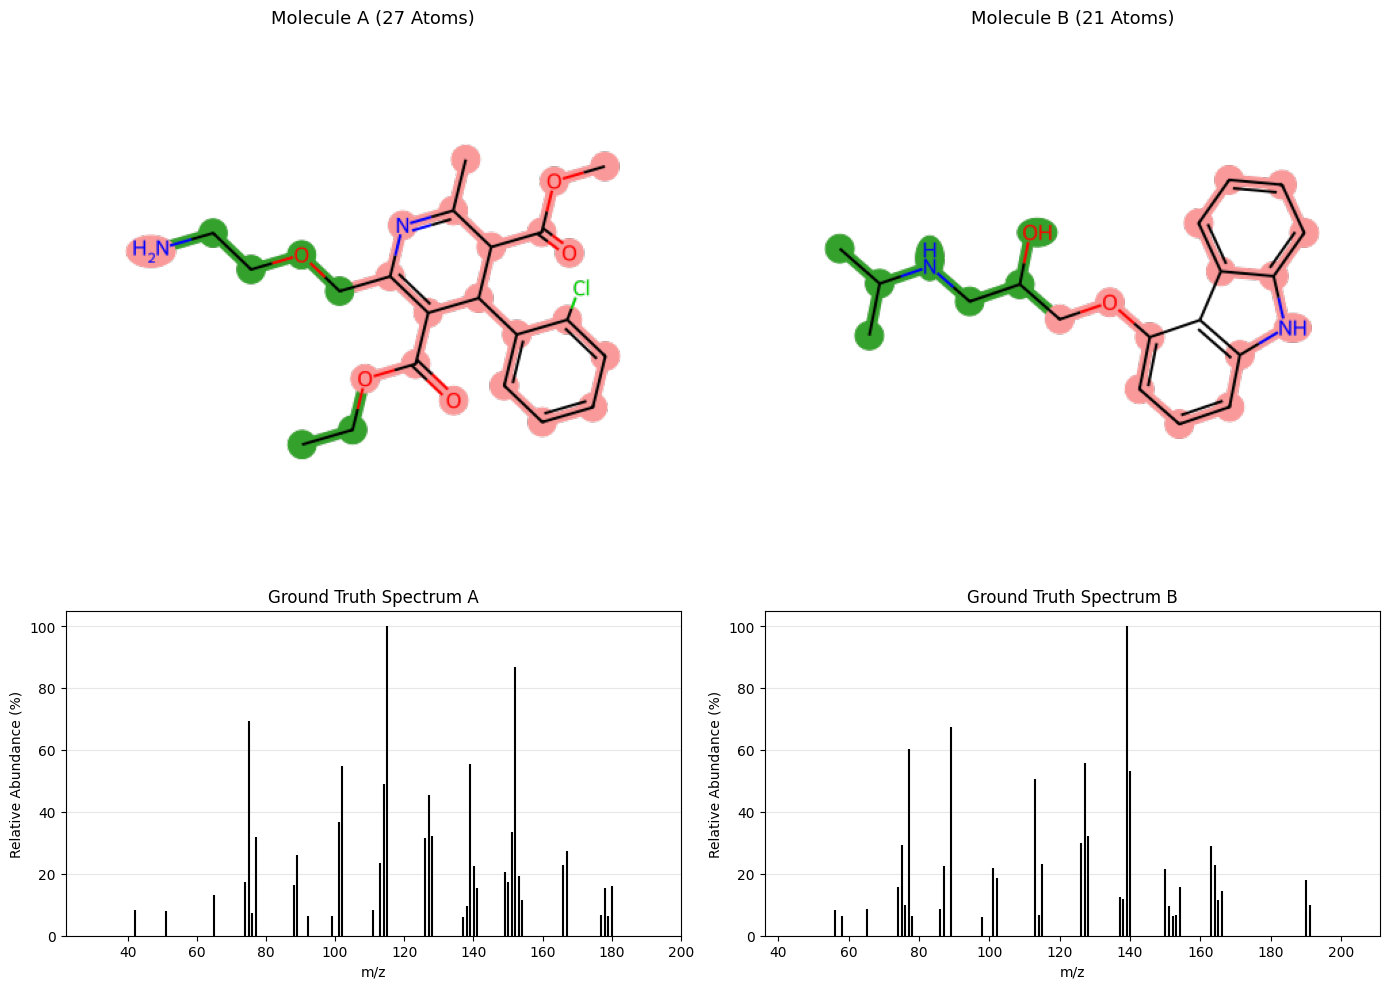

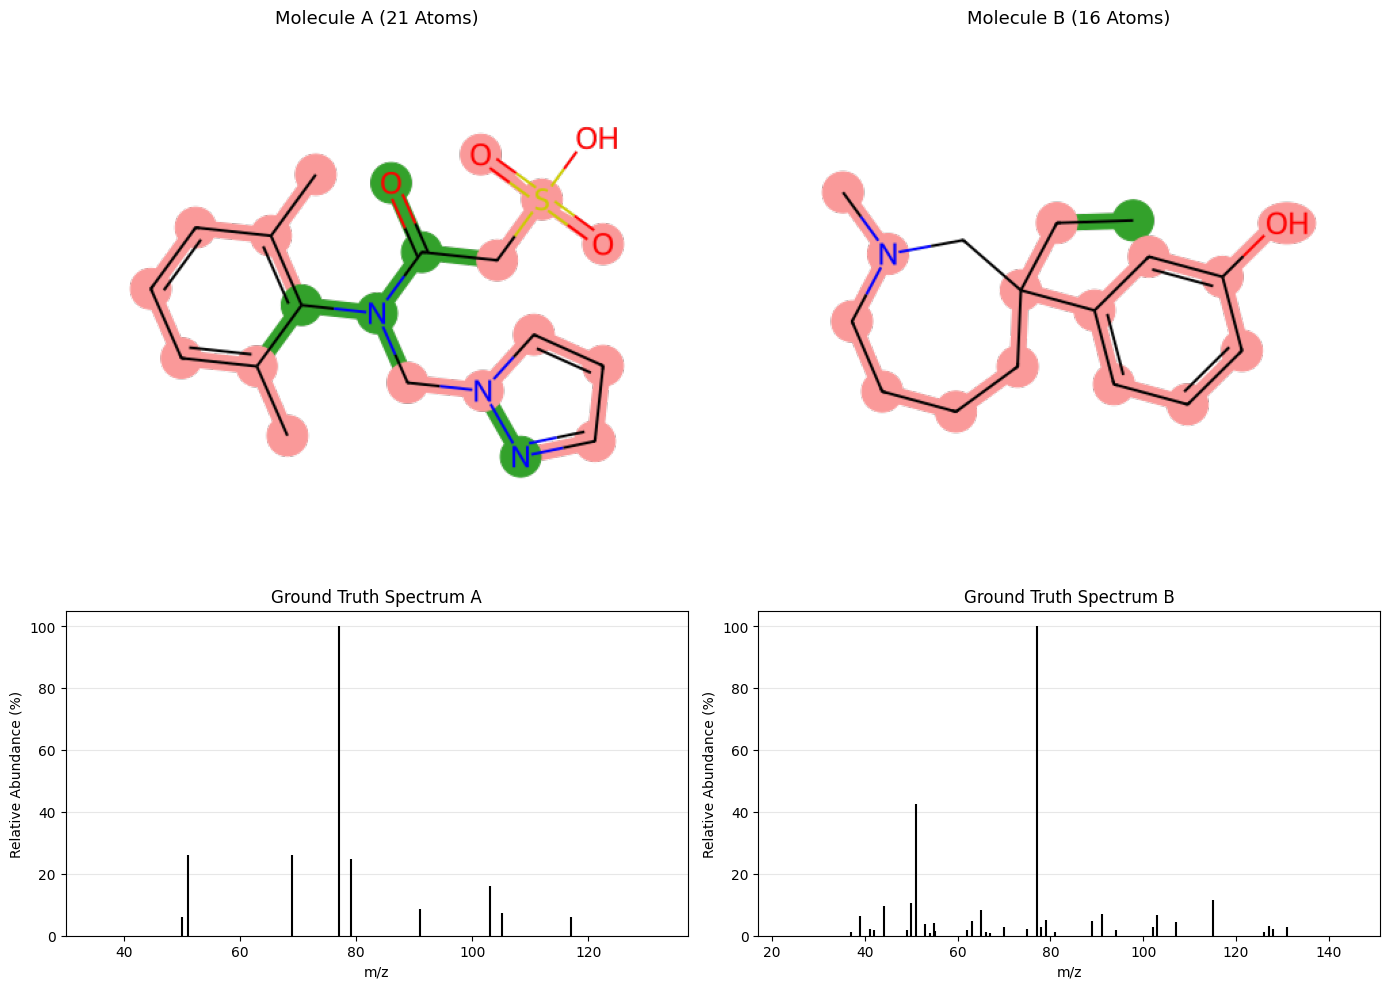

In [7]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import yaml
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, HTML
import os
import sys
from pathlib import Path

# --- Ensure custom modules are in the path ---
cwd = Path.cwd().parent.parent
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'flare'))
sys.path.insert(0, os.path.join(cwd, 'model', 'flare'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'transport_model'))

try:
    from data_loader import CrossModalPretrainDataset, cross_modal_collate_fn
    from cross_modal_pretrainer_new import CrossModalFlarePretrainer
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")

# ==========================================
# 0. CONFIGURATION PATHS
# ==========================================
TEMPLATE_CONFIG = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
CUSTOM_CONFIG = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
STAGE1_CKPT = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/flare/new/massformer_flare_stage1_new_best.pt"

SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
MOL_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
PREDS_CSV_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv"

# ==========================================
# 1. SETUP: Colors, Helpers, and Model
# ==========================================
MOTIF_COLORS = {
    0: (0.89, 0.10, 0.11), 1: (0.12, 0.47, 0.71), 2: (0.20, 0.63, 0.17),
    3: (1.00, 0.50, 0.00), 4: (0.42, 0.24, 0.60), 5: (0.89, 0.58, 0.18),
    6: (0.84, 0.15, 0.56), 7: (0.50, 0.50, 0.50), 8: (0.74, 0.74, 0.13),
    9: (0.09, 0.75, 0.81), 10: (0.68, 0.85, 0.90), 11: (0.98, 0.60, 0.60),
    12: (0.60, 0.98, 0.60), 13: (0.86, 0.80, 1.00), 14: (1.00, 0.85, 0.73)
}

def draw_motifs_on_molecule(smiles, motif_assignments):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None
    Chem.rdDepictor.Compute2DCoords(mol)
    
    highlight_atoms = []
    atom_colors = {}
    for atom_idx, motif_id in enumerate(motif_assignments):
        highlight_atoms.append(atom_idx)
        atom_colors[atom_idx] = MOTIF_COLORS.get(motif_id, (0.5, 0.5, 0.5))

    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)
    opts = drawer.drawOptions()
    opts.clearBackground = False
    drawer.DrawMolecule(mol, highlightAtoms=highlight_atoms, highlightAtomColors=atom_colors, highlightAtomRadii={i: 0.4 for i in highlight_atoms})
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

def plot_mass_spectrum(ax, peaks, title):
    """Renders a standard MS/MS stem plot on the given Matplotlib axis."""
    if not peaks or not isinstance(peaks, (list, tuple, np.ndarray)) or len(peaks) == 0:
        ax.text(0.5, 0.5, "No Peak Data", ha='center', va='center')
        ax.axis('off')
        return
        
    mzs = [p[0] for p in peaks]
    ints = [p[1] for p in peaks]
    
    max_int = max(ints) if ints else 1.0
    ints = [(i/max_int)*100 for i in ints]
    
    ax.vlines(mzs, 0, ints, color='black', linewidth=1.5)
    ax.set_xlabel("m/z", fontsize=10)
    ax.set_ylabel("Relative Abundance (%)", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, 105)
    
    min_mz, max_mz = min(mzs), max(mzs)
    ax.set_xlim(max(0, min_mz - 20), max_mz + 20)
    ax.grid(True, alpha=0.3, axis='y')

def load_and_merge_configs(template_path, custom_path):
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Using device: {device}")

# Load Configuration and Stage 1 Model
full_config = load_and_merge_configs(TEMPLATE_CONFIG, CUSTOM_CONFIG)

print(f"[*] Initializing Stage 1 Model architecture...")
model = CrossModalFlarePretrainer(model_config=full_config['model'], num_motifs=15).to(device)

print(f"[*] Loading Trained Stage 1 Weights from: {STAGE1_CKPT}")
model.load_state_dict(torch.load(STAGE1_CKPT, map_location=device))
model.eval()

# Load Datasets
print("[*] Loading Datasets & Predictions...")
dataset = CrossModalPretrainDataset(SPEC_DATA_PATH, MOL_DATA_PATH)
preds_df = pd.read_csv(PREDS_CSV_PATH)

def get_inference_data(spec_id):
    """Finds molecule, runs it through model, returns SMILES, Motif Assignments, and Raw Peaks."""
    target_idx = None
    for i in range(len(dataset.spec_df)):
        if dataset.spec_df.iloc[i]['spec_id'] == spec_id:
            target_idx = i
            break
    if target_idx is None: raise ValueError(f"Missing spec_id: {spec_id}")

    item = dataset[target_idx]
    row = dataset.spec_df.iloc[target_idx]
    
    target_mol = dataset.mol_lookup.get('mol').get(row['mol_id'])
    smiles = dataset.mol_lookup.get('smiles').get(row['mol_id'])
    raw_peaks = row['peaks'] 
    true_num_atoms = target_mol.GetNumAtoms()

    batch = cross_modal_collate_fn([item])
    batched_graphs, A_brics, _, _ = batch
    
    if isinstance(batched_graphs, dict):
        batched_graphs = {k: v.to(device) if hasattr(v, 'to') else v for k, v in batched_graphs.items()}
    A_brics = A_brics.to(device)

    with torch.no_grad():
        # Call forward_graph directly on the Stage 1 model
        _, S, _ = model.forward_graph(batched_graphs, A_brics, tau=0.5)

    S_np = S.squeeze(0).cpu().numpy()
    real_atom_S = S_np[1:true_num_atoms+1, :] 
    atom_assignments = np.argmax(real_atom_S, axis=1)

    return smiles, atom_assignments, raw_peaks

# ==========================================
# 2. EXTRACT WORST OFFENDERS
# ==========================================
NUM_TO_VISUALIZE = 3 

fps = preds_df[(preds_df['true_label'] == 0.0) & (preds_df['predicted_label'] == 1.0)].copy()
top_fps = fps.sort_values(by='prob_similarity', ascending=False).head(NUM_TO_VISUALIZE)

fns = preds_df[(preds_df['true_label'] == 1.0) & (preds_df['predicted_label'] == 0.0)].copy()
top_fns = fns.sort_values(by='prob_similarity', ascending=True).head(NUM_TO_VISUALIZE)

PAIRS_TO_VISUALIZE = []
for _, row in top_fps.iterrows():
    PAIRS_TO_VISUALIZE.append((row['name_main'], row['name_sub'], row['true_label'], row['prob_similarity'], "False Positive", row['mass_regime'], row['cosine_similarity']))
for _, row in top_fns.iterrows():
    PAIRS_TO_VISUALIZE.append((row['name_main'], row['name_sub'], row['true_label'], row['prob_similarity'], "False Negative", row['mass_regime'], row['cosine_similarity']))

# ==========================================
# 3. VISUALIZATION LOOP
# ==========================================
display(HTML("<h2>🔬 Motif & Spectra Analysis: Worst Offenders (Stage 1 Weights)</h2>"))

for name_A, name_B, true_label, pred_prob, err_type, mass_regime, cosine_similarity in PAIRS_TO_VISUALIZE:
    try:
        smiles_A, motifs_A, peaks_A = get_inference_data(name_A)
        smiles_B, motifs_B, peaks_B = get_inference_data(name_B)
    except Exception as e:
        print(f"[!] Skipping pair {name_A} & {name_B} due to error: {e}")
        continue
    
    img_A = draw_motifs_on_molecule(smiles_A, motifs_A)
    img_B = draw_motifs_on_molecule(smiles_B, motifs_B)
    
    # Render the Header
    color = "darkred" if err_type == "False Positive" else "darkblue"
    display(HTML(f"""
    <div style='border-left: 5px solid {color}; padding-left: 10px; margin-top: 20px; margin-bottom: 10px;'>
        <h4 style='margin:0;'>{err_type} | Regime: {mass_regime}</h4>
        <b>Pair:</b> {name_A} & {name_B} <br>
        <b>True Similarity:</b> {true_label} | <b>Predicted Probability:</b> {pred_prob:.4f} | <b>Cosine Similarity:</b> {cosine_similarity:.4f}
    </div>
    """))
    
    # --- UPGRADED: 2x2 Plotting Grid ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 0.6]})
    
    # Row 0: 2D Motif Structures
    if img_A:
        axes[0, 0].imshow(plt.imread(io.BytesIO(img_A), format='png'))
    axes[0, 0].set_title(f"Molecule A ({len(motifs_A)} Atoms)", fontsize=13)
    axes[0, 0].axis('off')
    
    if img_B:
        axes[0, 1].imshow(plt.imread(io.BytesIO(img_B), format='png'))
    axes[0, 1].set_title(f"Molecule B ({len(motifs_B)} Atoms)", fontsize=13)
    axes[0, 1].axis('off')
    
    # Row 1: Ground Truth Mass Spectra
    plot_mass_spectrum(axes[1, 0], peaks_A, "Ground Truth Spectrum A")
    plot_mass_spectrum(axes[1, 1], peaks_B, "Ground Truth Spectrum B")
    
    plt.tight_layout()
    plt.show()

In [20]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import yaml
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display, HTML
import os
import sys
from pathlib import Path

# --- Ensure custom modules are in the path ---
cwd = Path.cwd().parent.parent
parent_directory = os.path.dirname(cwd.parent)
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'flare'))
sys.path.insert(0, os.path.join(cwd, 'model', 'flare'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
sys.path.insert(0, os.path.join(parent_directory, 'tmach007', 'massformer', 'src', 'massformer'))
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'transport_model'))

try:
    from data_loader import CrossModalPretrainDataset, cross_modal_collate_fn
    from cross_modal_pretrainer_new import CrossModalFlarePretrainer
    from siamese_sinkhorn_new import SiameseSinkhornPredictor 
except ImportError as e:
    print(f"[-] Error importing custom modules: {e}")

# ==========================================
# 0. CONFIGURATION PATHS
# ==========================================
TEMPLATE_CONFIG = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
CUSTOM_CONFIG = "/data/nas-gpu/wang/tmach007/massformer/config/demo/demo_eval.yml"
STAGE1_CKPT = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/flare/new/massformer_flare_stage1_new_best.pt"
STAGE2_CKPT = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/flare/new/siamese_sinkhorn_best.pt"
META_DIM = 81 

SPEC_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
MOL_DATA_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
PREDS_CSV_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/flare/test_predictions_new.csv"

# ==========================================
# 1. SETUP: Colors, Helpers, and Model
# ==========================================
MOTIF_COLORS = {
    0: (0.89, 0.10, 0.11), 1: (0.12, 0.47, 0.71), 2: (0.20, 0.63, 0.17),
    3: (1.00, 0.50, 0.00), 4: (0.42, 0.24, 0.60), 5: (0.89, 0.58, 0.18),
    6: (0.84, 0.15, 0.56), 7: (0.50, 0.50, 0.50), 8: (0.74, 0.74, 0.13),
    9: (0.09, 0.75, 0.81), 10: (0.68, 0.85, 0.90), 11: (0.98, 0.60, 0.60),
    12: (0.60, 0.98, 0.60), 13: (0.86, 0.80, 1.00), 14: (1.00, 0.85, 0.73)
}

def draw_motifs_on_molecule(smiles, motif_assignments):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None
    Chem.rdDepictor.Compute2DCoords(mol)
    
    highlight_atoms = []
    atom_colors = {}
    for atom_idx, motif_id in enumerate(motif_assignments):
        highlight_atoms.append(atom_idx)
        atom_colors[atom_idx] = MOTIF_COLORS.get(motif_id, (0.5, 0.5, 0.5))

    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)
    opts = drawer.drawOptions()
    opts.clearBackground = False
    drawer.DrawMolecule(mol, highlightAtoms=highlight_atoms, highlightAtomColors=atom_colors, highlightAtomRadii={i: 0.4 for i in highlight_atoms})
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

def plot_mass_spectrum(ax, peaks, title):
    """Renders a standard MS/MS stem plot on the given Matplotlib axis."""
    if not peaks or not isinstance(peaks, (list, tuple, np.ndarray)) or len(peaks) == 0:
        ax.text(0.5, 0.5, "No Peak Data", ha='center', va='center')
        ax.axis('off')
        return
        
    # Extract m/z and intensities
    mzs = [p[0] for p in peaks]
    ints = [p[1] for p in peaks]
    
    # Normalize intensities to 0-100% for standard visualization
    max_int = max(ints) if ints else 1.0
    ints = [(i/max_int)*100 for i in ints]
    
    # Draw spectral lines
    ax.vlines(mzs, 0, ints, color='black', linewidth=1.5)
    ax.set_xlabel("m/z", fontsize=10)
    ax.set_ylabel("Relative Abundance (%)", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, 105)
    
    # Pad the x-axis slightly
    min_mz, max_mz = min(mzs), max(mzs)
    ax.set_xlim(max(0, min_mz - 20), max_mz + 20)
    ax.grid(True, alpha=0.3, axis='y')

def load_and_merge_configs(template_path, custom_path):
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Using device: {device}")

# Load Configuration and Model
full_config = load_and_merge_configs(TEMPLATE_CONFIG, CUSTOM_CONFIG)
model = SiameseSinkhornPredictor(model_config=full_config['model'], stage1_ckpt_path=STAGE1_CKPT, meta_dim=META_DIM).to(device)
model.load_state_dict(torch.load(STAGE2_CKPT, map_location=device))
model.eval()

# Load Datasets
print("[*] Loading Datasets & Predictions...")
dataset = CrossModalPretrainDataset(SPEC_DATA_PATH, MOL_DATA_PATH)
preds_df = pd.read_csv(PREDS_CSV_PATH)

def get_inference_data(spec_id):
    """Finds molecule, runs it through model, returns SMILES, Motif Assignments, and Raw Peaks."""
    target_idx = None
    for i in range(len(dataset.spec_df)):
        if dataset.spec_df.iloc[i]['spec_id'] == spec_id:
            target_idx = i
            break
    if target_idx is None: raise ValueError(f"Missing spec_id: {spec_id}")

    item = dataset[target_idx]
    row = dataset.spec_df.iloc[target_idx]
    
    target_mol = dataset.mol_lookup.get('mol').get(row['mol_id'])
    smiles = dataset.mol_lookup.get('smiles').get(row['mol_id'])
    raw_peaks = row['peaks'] # NEW: Extract raw peaks directly from the dataframe
    true_num_atoms = target_mol.GetNumAtoms()

    batch = cross_modal_collate_fn([item])
    batched_graphs, A_brics, _, _ = batch
    
    if isinstance(batched_graphs, dict):
        batched_graphs = {k: v.to(device) if hasattr(v, 'to') else v for k, v in batched_graphs.items()}
    A_brics = A_brics.to(device)

    with torch.no_grad():
        _, S, _ = model.motif_extractor.forward_graph(batched_graphs, A_brics, tau=0.5)

    S_np = S.squeeze(0).cpu().numpy()
    real_atom_S = S_np[1:true_num_atoms+1, :] 
    atom_assignments = np.argmax(real_atom_S, axis=1)

    return smiles, atom_assignments, raw_peaks

# ==========================================
# 2. EXTRACT WORST OFFENDERS
# ==========================================
NUM_TO_VISUALIZE = 3 

fps = preds_df[(preds_df['true_label'] == 0.0) & (preds_df['predicted_label'] == 1.0)].copy()
top_fps = fps.sort_values(by='prob_similarity', ascending=False).head(NUM_TO_VISUALIZE)

fns = preds_df[(preds_df['true_label'] == 1.0) & (preds_df['predicted_label'] == 0.0)].copy()
top_fns = fns.sort_values(by='prob_similarity', ascending=True).head(NUM_TO_VISUALIZE)

PAIRS_TO_VISUALIZE = []
for _, row in top_fps.iterrows():
    PAIRS_TO_VISUALIZE.append((row['name_main'], row['name_sub'], row['true_label'], row['prob_similarity'], "False Positive", row['mass_regime'], row['cosine_similarity']))
for _, row in top_fns.iterrows():
    PAIRS_TO_VISUALIZE.append((row['name_main'], row['name_sub'], row['true_label'], row['prob_similarity'], "False Negative", row['mass_regime'], row['cosine_similarity']))

# ==========================================
# 3. VISUALIZATION LOOP
# ==========================================
display(HTML("<h2>🔬 Motif & Spectra Analysis: Worst Offenders</h2>"))

for name_A, name_B, true_label, pred_prob, err_type, mass_regime, cosine_similarity in PAIRS_TO_VISUALIZE:
    try:
        smiles_A, motifs_A, peaks_A = get_inference_data(name_A)
        smiles_B, motifs_B, peaks_B = get_inference_data(name_B)
    except Exception as e:
        print(f"[!] Skipping pair {name_A} & {name_B} due to error: {e}")
        continue
    
    img_A = draw_motifs_on_molecule(smiles_A, motifs_A)
    img_B = draw_motifs_on_molecule(smiles_B, motifs_B)
    
    # Render the Header
    color = "darkred" if err_type == "False Positive" else "darkblue"
    display(HTML(f"""
    <div style='border-left: 5px solid {color}; padding-left: 10px; margin-top: 20px; margin-bottom: 10px;'>
        <h4 style='margin:0;'>{err_type} | Regime: {mass_regime}</h4>
        <b>Pair:</b> {name_A} & {name_B} <br>
        <b>True Similarity:</b> {true_label} | <b>Predicted Probability:</b> {pred_prob:.4f} | <b>Cosine Similarity:</b> {cosine_similarity:.4f}
    </div>
    """))
    
    # --- UPGRADED: 2x2 Plotting Grid ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 0.6]})
    
    # Row 0: 2D Motif Structures
    if img_A:
        axes[0, 0].imshow(plt.imread(io.BytesIO(img_A), format='png'))
    axes[0, 0].set_title(f"Molecule A ({len(motifs_A)} Atoms)", fontsize=13)
    axes[0, 0].axis('off')
    
    if img_B:
        axes[0, 1].imshow(plt.imread(io.BytesIO(img_B), format='png'))
    axes[0, 1].set_title(f"Molecule B ({len(motifs_B)} Atoms)", fontsize=13)
    axes[0, 1].axis('off')
    
    # Row 1: Ground Truth Mass Spectra
    plot_mass_spectrum(axes[1, 0], peaks_A, "Ground Truth Spectrum A")
    plot_mass_spectrum(axes[1, 1], peaks_B, "Ground Truth Spectrum B")
    
    plt.tight_layout()
    plt.show()

[-] Error importing custom modules: cannot import name 'CrossModalFlarePretrainer' from 'cross_modal_pretrainer_new' (/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/model/flare/cross_modal_pretrainer_new.py)
[*] Using device: cuda


NameError: name 'SiameseSinkhornPredictor' is not defined

## New physics aware model metrics

[*] Using device: cuda
[*] Loading Dataset...
[*] Loading Spectral Data from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_COMBINED.pkl
[*] Loading Molecular Data from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df_COMBINED.pkl
[+] Dataset initialized with 260706 valid molecule-spectrum pairs.
[*] Loading Model Configurations...


/tmp/ipykernel_3420980/1697026063.py:211: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(args.checkpoint, map_location=device))


[+] Loaded weights from /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/flare/physics_v1/bifurcated_flare_best.pt

[*] Generating Inline Visualizations...


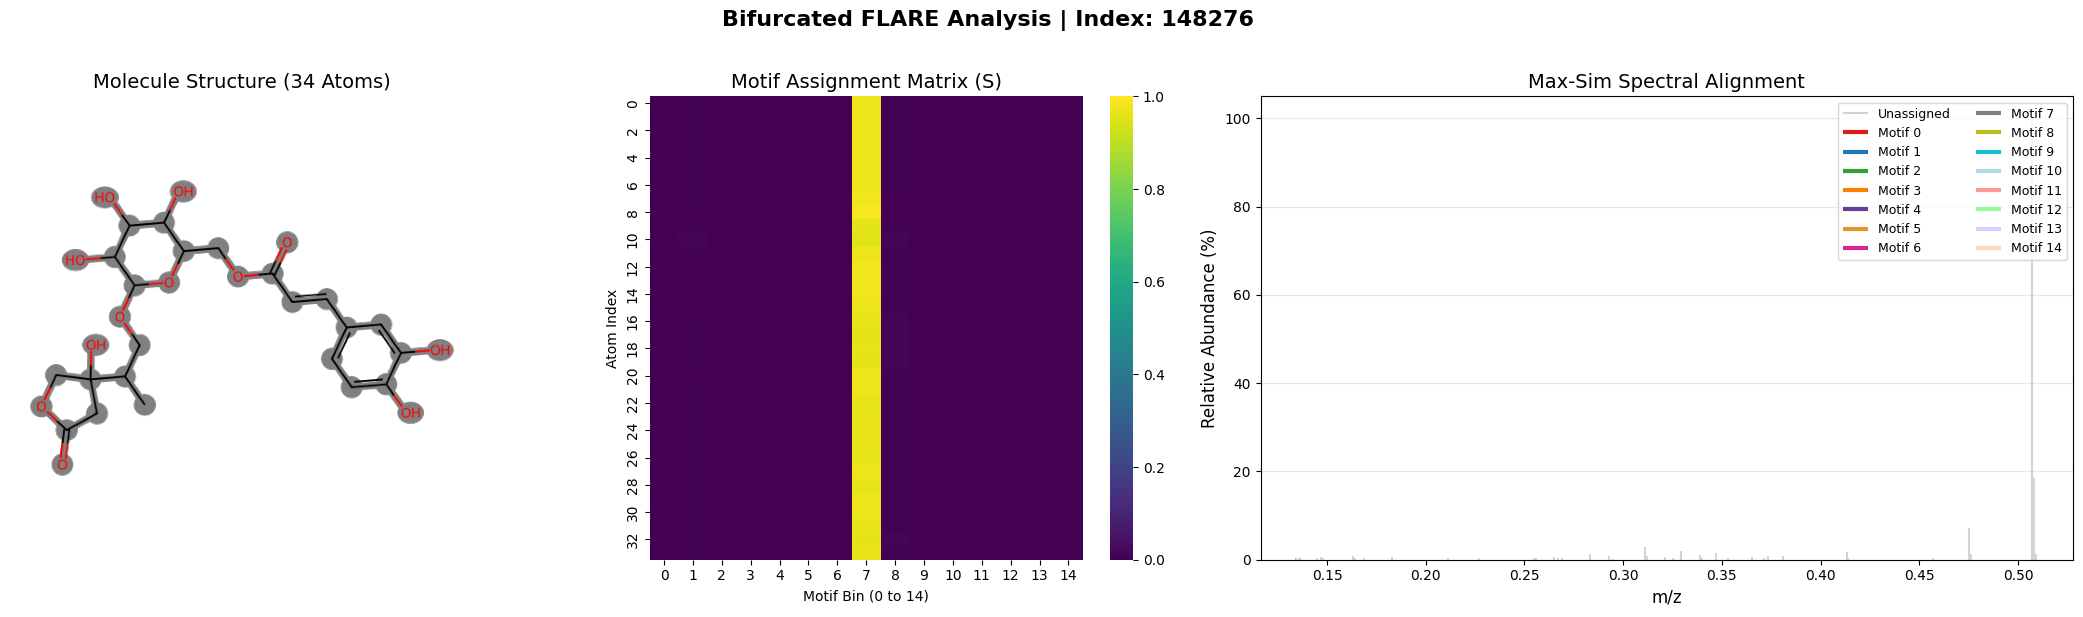

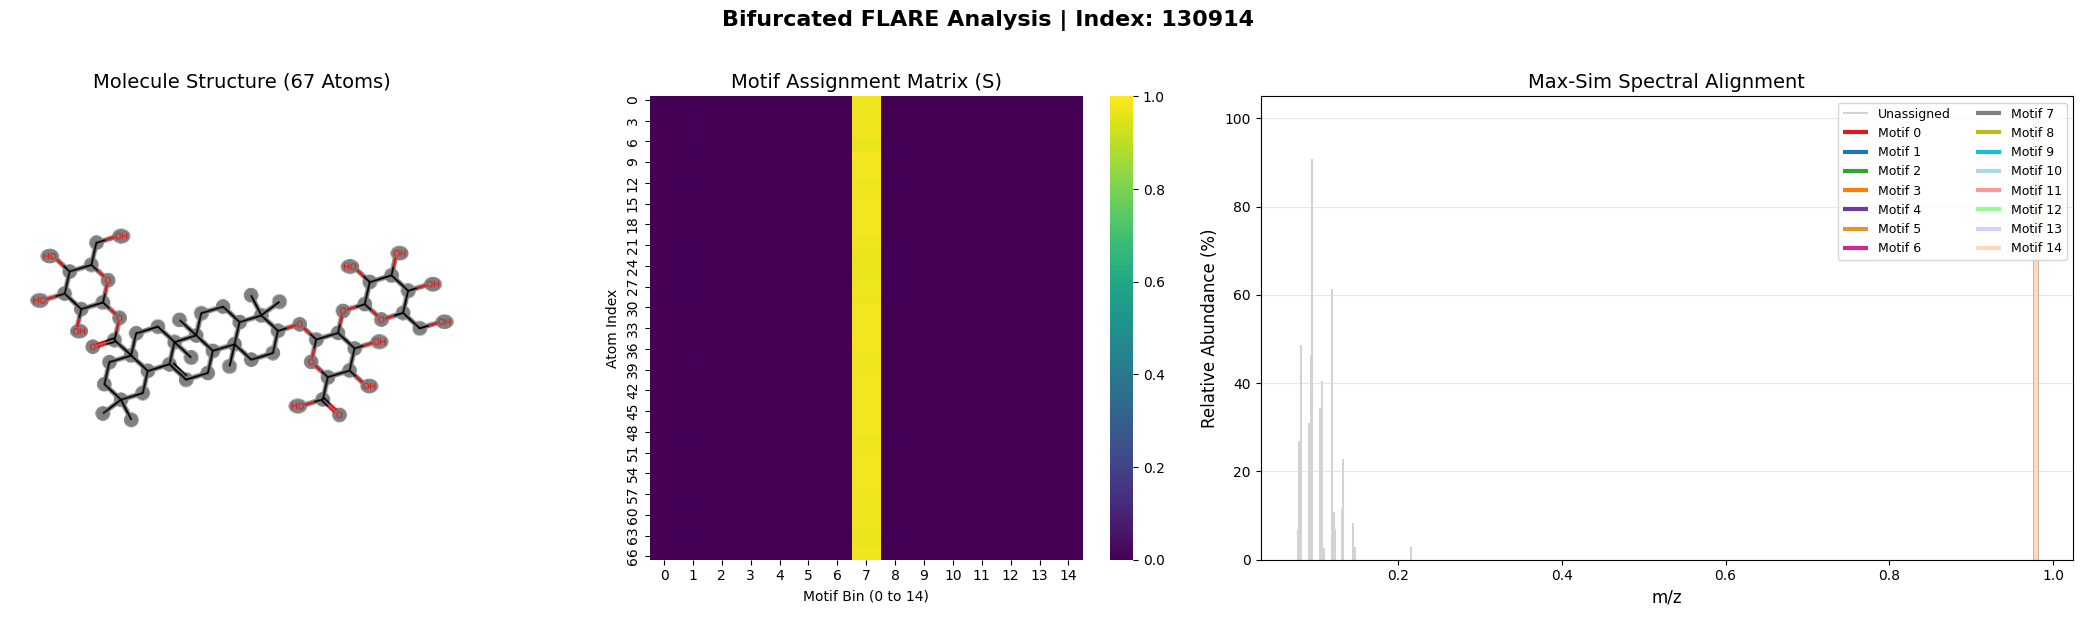

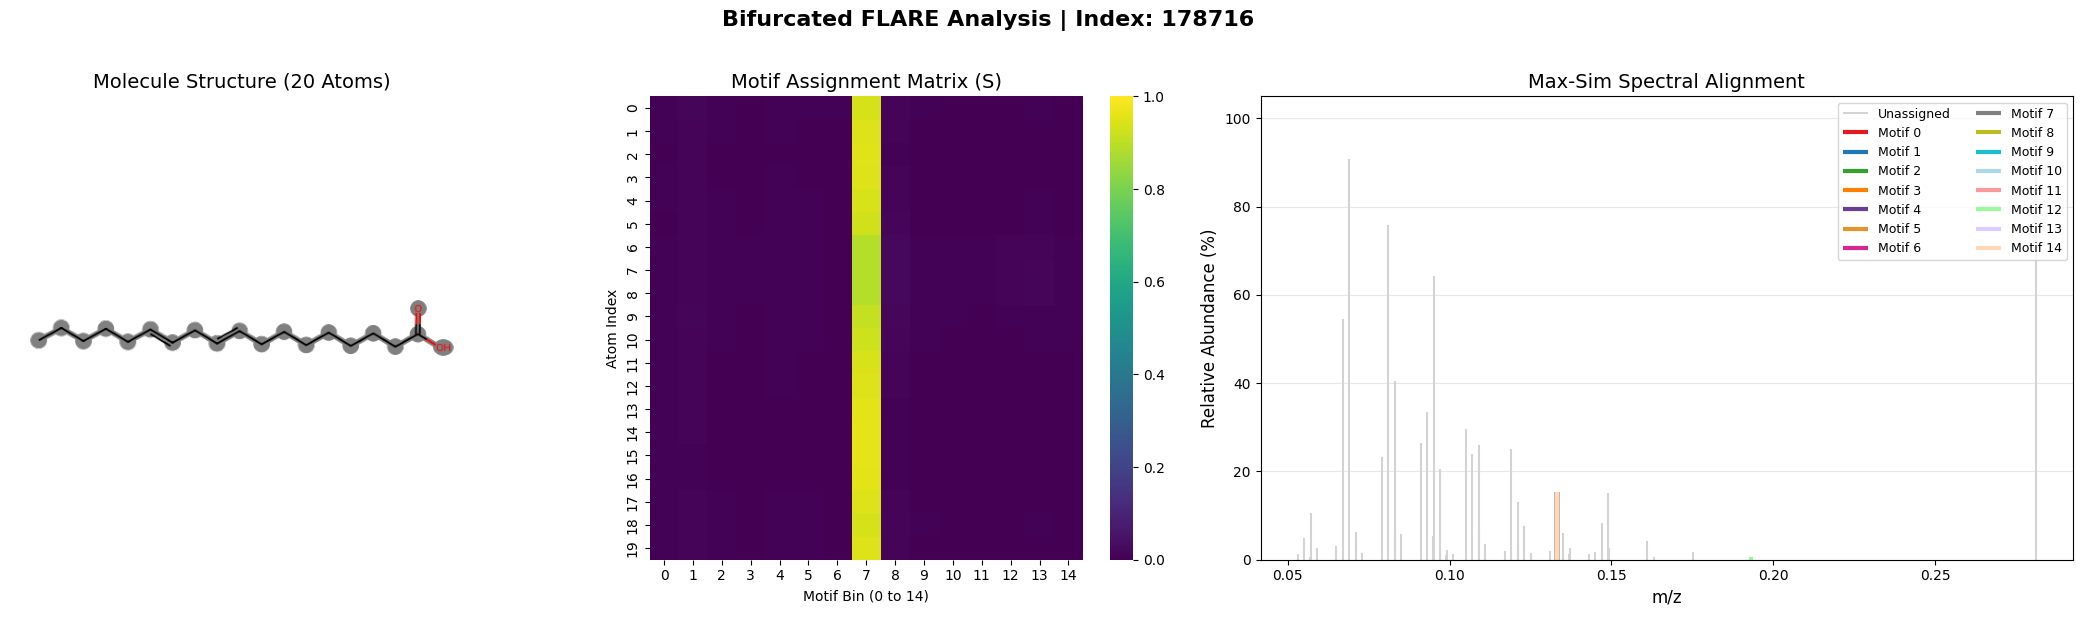

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np
import pandas as pd
import os
import io
from pathlib import Path
import sys
import yaml
import random

# RDKit Imports
from rdkit import Chem
from rdkit.Chem import Draw

# Ensures plots are rendered inline inside the notebook
%matplotlib inline

# ==========================================
# 0. SETUP PATHS
# ==========================================
cwd = Path.cwd().parent.parent
sys.path.insert(0, os.path.join(cwd, 'data_loaders', 'flare'))
sys.path.insert(0, os.path.join(cwd, 'model', 'flare'))
sys.path.insert(0, os.path.join(cwd, 'model', 'transport_model', 'bifurcate'))
parent_directory = cwd.parent
sys.path.insert(0, os.path.join(parent_directory, 'massformer', 'src', 'massformer'))

try:
    from data_loader import CrossModalPretrainDataset, cross_modal_collate_fn
    from cross_modal_pretrainer_new import BifurcatedCrossModalPretrainer
except ImportError as e:
    print(f"[-] Error importing custom modules. Check your sys.path! Error: {e}")

# ==========================================
# 1. NOTEBOOK CONFIGURATION
# ==========================================
class Config:
    spec_data_path  = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_COMBINED.pkl"
    mol_data_path   = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df_COMBINED.pkl"
    # UPDATED: Point to the new bifurcated checkpoint output directory
    checkpoint      = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/trained_model/flare/physics_v1/bifurcated_flare_best.pt" 
    template_config = "/data/nas-gpu/wang/tmach007/massformer/config/template.yml"
    custom_config   = "/data/nas-gpu/wang/tmach007/massformer/config/demo.yml"
    num_samples     = 3   
    max_peaks       = 60

args = Config()

# Pre-defined professional color palette for 15 motifs (RGB tuples 0-1)
MOTIF_COLORS = {
    0: (0.89, 0.10, 0.11), 1: (0.12, 0.47, 0.71), 2: (0.20, 0.63, 0.17),
    3: (1.00, 0.50, 0.00), 4: (0.42, 0.24, 0.60), 5: (0.89, 0.58, 0.18),
    6: (0.84, 0.15, 0.56), 7: (0.50, 0.50, 0.50), 8: (0.74, 0.74, 0.13),
    9: (0.09, 0.75, 0.81), 10: (0.68, 0.85, 0.90), 11: (0.98, 0.60, 0.60),
    12: (0.60, 0.98, 0.60), 13: (0.86, 0.80, 1.00), 14: (1.00, 0.85, 0.73)
}

def load_and_merge_configs(template_path, custom_path):
    with open(template_path, 'r', encoding='utf-8') as f: config = yaml.safe_load(f)
    if os.path.exists(custom_path):
        with open(custom_path, 'r', encoding='utf-8') as f: custom_config = yaml.safe_load(f)
        for section, subdict in custom_config.items():
            if isinstance(subdict, dict):
                if section not in config: config[section] = {}
                for k, v in subdict.items(): config[section][k] = v
            else: config[section] = subdict
    return config

# ==========================================
# 2. DRAWING HELPERS
# ==========================================
def draw_motifs_on_molecule(smiles, motif_assignments):
    """Renders a 2D molecule with atoms highlighted by motif color using RDKit."""
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None
    Chem.rdDepictor.Compute2DCoords(mol)
    
    highlight_atoms = []
    atom_colors = {}
    for atom_idx, motif_id in enumerate(motif_assignments):
        highlight_atoms.append(atom_idx)
        atom_colors[atom_idx] = MOTIF_COLORS.get(motif_id, (0.5, 0.5, 0.5))

    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(500, 500)
    opts = drawer.drawOptions()
    opts.clearBackground = False
    # Ensure drawing matches the exact number of atoms given by the assignment
    drawer.DrawMolecule(mol, highlightAtoms=highlight_atoms, highlightAtomColors=atom_colors, highlightAtomRadii={i: 0.45 for i in highlight_atoms})
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

def plot_mass_spectrum(ax, peaks_np, peak_mask_np, best_peak_indices):
    """Renders a standard MS/MS stem plot with motif-colored alignments."""
    mz_values, intensities = peaks_np[:, 0], peaks_np[:, 1]
    valid_peak_mask = ~peak_mask_np
    
    mz_valid = mz_values[valid_peak_mask]
    int_valid = intensities[valid_peak_mask]
    
    if len(int_valid) == 0:
        ax.text(0.5, 0.5, "No Peak Data", ha='center', va='center')
        ax.axis('off')
        return
        
    # Normalize intensities to 0-100%
    max_int = max(int_valid) if len(int_valid) > 0 else 1.0
    int_norm = (int_valid / max_int) * 100.0
    
    # 1. Plot all background/unassigned peaks in light gray
    ax.vlines(mz_valid, 0, int_norm, color='lightgray', linewidth=1.5, label='Unassigned')
    
    # 2. Overlay the peaks claimed by Max-Sim alignment
    claimed_peaks = set()
    for motif_idx, peak_idx in enumerate(best_peak_indices):
        if not peak_mask_np[peak_idx]: 
            mz = peaks_np[peak_idx, 0]
            intensity = (peaks_np[peak_idx, 1] / max_int) * 100.0
            
            ax.vlines(mz, 0, intensity, color=MOTIF_COLORS.get(motif_idx, (0,0,0)), 
                      linewidth=3.0, label=f'Motif {motif_idx}' if motif_idx not in claimed_peaks else "")
            claimed_peaks.add(motif_idx)

    ax.set_title("Max-Sim Spectral Alignment", fontsize=14)
    ax.set_xlabel("m/z", fontsize=12)
    ax.set_ylabel("Relative Abundance (%)", fontsize=12)
    ax.set_ylim(0, 105)
    
    # Clean up duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3, axis='y')

# ==========================================
# 3. MASTER PLOTTING FUNCTION
# ==========================================
def plot_motif_analysis_inline(smiles, S_matrix, peaks, peak_mask, sim_matrix, sample_idx):
    S_np = S_matrix.cpu().numpy()
    peaks_np = peaks.cpu().numpy()
    peak_mask_np = peak_mask.cpu().numpy()
    
    # Extract actual atom count from RDKit to slice padding accurately
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return
    num_atoms = mol.GetNumAtoms()
    
    # Slice S matrix to real atoms only
    S_valid = S_np[:num_atoms, :]
    dominant_motifs = np.argmax(S_valid, axis=1)
    
    # Get Peak Alignments (Max-Sim)
    best_peak_indices = torch.argmax(sim_matrix, dim=1).cpu().numpy()
    
    # Create Figure
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), gridspec_kw={'width_ratios': [1, 0.8, 1.2]})
    # UPDATED: Changed Title
    fig.suptitle(f"Bifurcated FLARE Analysis | Index: {sample_idx}", fontsize=16, fontweight='bold', y=1.02)

    # --- PANEL 1: RDKit Graph ---
    ax_graph = axes[0]
    img_bytes = draw_motifs_on_molecule(smiles, dominant_motifs)
    if img_bytes:
        ax_graph.imshow(plt.imread(io.BytesIO(img_bytes), format='png'))
    ax_graph.axis('off')
    ax_graph.set_title(f"Molecule Structure ({num_atoms} Atoms)", fontsize=14)

    # --- PANEL 2: Heatmap ---
    ax_heat = axes[1]
    sns.heatmap(S_valid, cmap="viridis", ax=ax_heat, vmin=0, vmax=1)
    ax_heat.set_title("Motif Assignment Matrix (S)", fontsize=14)
    ax_heat.set_xlabel("Motif Bin (0 to 14)")
    ax_heat.set_ylabel("Atom Index")

    # --- PANEL 3: Stem Plot Spectrum ---
    plot_mass_spectrum(axes[2], peaks_np, peak_mask_np, best_peak_indices)

    plt.tight_layout()
    plt.show() 

# ==========================================
# 4. EXECUTION LOGIC
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Using device: {device}")

print("[*] Loading Dataset...")
dataset = CrossModalPretrainDataset(
    spec_data_path=args.spec_data_path,
    mol_data_path=args.mol_data_path,
    max_peaks=args.max_peaks
)

print("[*] Loading Model Configurations...")
full_config = load_and_merge_configs(args.template_config, args.custom_config)
model_config = full_config['model']

# Force graph features to prevent Siamese wrapper crash
if 'embed_types' in model_config:
    model_config['embed_types'] = ['gf_v2']
else:
    model_config['embed_types'] = ['gf_v2']

# UPDATED: Initialize the new model
model = BifurcatedCrossModalPretrainer(model_config=model_config, num_motifs=15).to(device)

if os.path.exists(args.checkpoint):
    model.load_state_dict(torch.load(args.checkpoint, map_location=device))
    print(f"[+] Loaded weights from {args.checkpoint}")
else:
    print(f"[!] WARNING: Checkpoint not found. Visualizing RANDOM weights.")

model.eval()

# Sample random indices from the dataset
random_indices = random.sample(range(len(dataset.spec_df)), args.num_samples)

print("\n[*] Generating Inline Visualizations...")
with torch.no_grad():
    for idx in random_indices:
        # Extract Item and Exact SMILES
        item = dataset[idx]
        row = dataset.spec_df.iloc[idx]
        smiles = dataset.mol_lookup.get('smiles').get(row['mol_id'])
        
        # Manually collate a batch of size 1
        batch = cross_modal_collate_fn([item])
        batched_graphs, A_brics, _, peaks, peak_mask, _ = batch

        if isinstance(batched_graphs, dict):
            batched_graphs = {k: v.to(device) if hasattr(v, 'to') else v for k, v in batched_graphs.items()}
        elif hasattr(batched_graphs, 'to'):
            batched_graphs = batched_graphs.to(device)
            
        A_brics = A_brics.to(device)
        peaks = peaks.to(device)
        peak_mask = peak_mask.to(device)

        # Forward Pass
        Z_graph, Z_spec, S = model(batched_graphs, A_brics, peaks, peak_mask)
        
        # UPDATED: L2 Normalize embeddings before matmul to correctly reflect Cosine Similarity 
        # (This matches the new Set-to-Set loss function dynamics)
        z_g = F.normalize(Z_graph[0], dim=-1) # [15, 768]
        z_s = F.normalize(Z_spec[0], dim=-1)  # [M, 768]
        M = z_s.shape[0]
        
        sim_matrix = torch.matmul(z_g, z_s.t()) 
        mask_expand = peak_mask[0].view(1, M).expand(15, M)
        sim_matrix.masked_fill_(mask_expand, -1e4)
        
        # Render the 3-Panel Plot
        plot_motif_analysis_inline(smiles, S[0], peaks[0], peak_mask[0], sim_matrix, sample_idx=idx)